# Préparation & Nettoyage des Données
## Base OQAI CNL1



## 1. Configuration

In [36]:
# Configuration
 
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (11, 4)})
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)


## 2. Chargement des données

In [37]:
BASE        = Path("../data/cln1/raw")
DIR_COMPORT = BASE / "Questionnaires_Comportement"
DIR_CONFORT = BASE / "Mesures_Confort_Dynamique"
DIR_POLLUT  = BASE / "Mesures_Polluants"
DIR_IDENT   = BASE / "Identite_Logement"
DIR_DICO    = BASE / "Dictionnaires"

sem  = pd.read_csv(DIR_COMPORT / 'CNL1_SEMAINIER_DATA.txt',  sep='\t', parse_dates=['DATE'], dayfirst=True)
jour = pd.read_csv(DIR_COMPORT / 'CNL1_JOURNALIER_DATA.csv', sep=';')
co2  = pd.read_csv(DIR_CONFORT  / 'CNL1_SERIE_CO2.txt',      sep='\t', parse_dates=['DATE_HEURE']).drop(columns=['CODEPARAM'])
tpt  = pd.read_csv(DIR_CONFORT  / 'CNL1_SERIE_TPT.txt',      sep='\t', parse_dates=['DATE_HEURE']).drop(columns=['CODEPARAM'])
hre  = pd.read_csv(DIR_CONFORT  / 'CNL1_SERIE_HRE.txt',      sep='\t', parse_dates=['DATE_HEURE']).drop(columns=['CODEPARAM'])
co   = pd.read_csv(DIR_POLLUT   / 'CNL1_SERIE_CO.txt',       sep='\t', parse_dates=['DATE_HEURE']).drop(columns=['CODEPARAM'])
log  = pd.read_csv(DIR_IDENT    / 'CNL1_LISTE_LOGEMENT.csv', encoding='utf-16', sep=';', parse_dates=['DVISIT1','DVISIT2'])
pie  = pd.read_csv(DIR_IDENT    / 'CNL1_LISTE_PIECE.csv',    encoding='utf-16', sep=';')

DATASETS = {'Semainier': sem, 'Journalier': jour, 'CO2': co2,
            'TPT': tpt, 'HRE': hre, 'CO': co, 'Logements': log, 'Pièces': pie}

print('Dataset        Lignes  Colonnes')
print('-' * 35)
for name, df in DATASETS.items():
    print(f'{name:<14} {df.shape[0]:>7,}  {df.shape[1]:>6}')

Dataset        Lignes  Colonnes
-----------------------------------
Semainier      1,386,000       5
Journalier     197,640      16
CO2            514,425       6
TPT            1,056,234       6
HRE            1,054,178       6
CO             2,885,163       6
Logements          567       7
Pièces              62       3


### 2.2 Fichiers questionnaires et comportement

In [38]:
q_ind  = pd.read_csv(DIR_COMPORT / 'CNL1_Q_INDIVIDU_DATA.csv',
                     sep=';', encoding='latin-1')
q_men  = pd.read_csv(DIR_COMPORT / 'CNL1_Q_LOGEMENT_MENAGE_DATA.csv',
                     sep=';', encoding='latin-1')
q_pie  = pd.read_csv(DIR_COMPORT / 'CNL1_Q_PIECE_DATA.csv',
                     sep=';', encoding='latin-1')
q_te   = pd.read_csv(DIR_COMPORT / 'CNL1_Q_TE_DATA.csv',
                     sep=';', encoding='latin-1')
beta   = pd.read_csv(DIR_COMPORT / 'CNL1_INFOS_BETA.csv',
                     sep=';', encoding='utf-16')

Q_DATASETS = {
    'Q_Individu'  : q_ind,
    'Q_Menage'    : q_men,
    'Q_Piece'     : q_pie,
    'Q_TE'        : q_te,
    'INFOS_BETA'  : beta,
}

print('Dataset            Lignes  Colonnes')
print('-' * 42)
for name, df in Q_DATASETS.items():
    print(f'{name:<18} {df.shape[0]:>7,}  {df.shape[1]:>6}')

Dataset            Lignes  Colonnes
------------------------------------------
Q_Individu           1,612      42
Q_Menage               567     351
Q_Piece              4,691      86
Q_TE                 1,130       7
INFOS_BETA           1,612      16


In [39]:
# MAPPINGS & DICTIONNAIRES

# Pièces
ROOM_ID = {
    11: 1,  12: 1,  13: 1,  14: 1,  15: 1,  16: 1,   # Chambre
    20: 2,  21: 2,  22: 2,  23: 2,  24: 2,  25: 2,   # Séjour/Salon
    55: 3,                                              # Studio
    17: 4,  18: 4,  19: 4,                             # Cuisine
    29: 5,  30: 5,  31: 5,                             # Salle de bains
    26: 6,  27: 6,                                     # Buanderie
    32: 7,  33: 7,  34: 7,                             # WC
    35: 8,  36: 8,  37: 8,                             # Bureau
    38: 9,                                              # Chaufferie
    41: 10, 42: 10, 43: 10, 44: 10, 45: 10, 46: 10,  # Cave/Grenier
    50: 11, 51: 11,                                    # Garage
    90: 12,                                             # Extérieur
    60: 13, 61: 13, 62: 13, 64: 13, 65: 13,           # Autre pièce
    74: 13, 75: 13, 76: 13, 77: 13, 78: 13, 79: 13,  # Autre pièce
    80: 13, 81: 13, 82: 13, 83: 13, 84: 13, 85: 13,  # Autre pièce
    86: 13, 87: 13, 88: 13, 99: 13,                   # Autre pièce
}
ROOM_LABEL = {
    1:'Chambre', 2:'Séjour/Salon', 3:'Studio', 4:'Cuisine',
    5:'Salle de bains', 6:'Buanderie', 7:'WC', 8:'Bureau',
    9:'Chaufferie', 10:'Cave/Grenier', 11:'Garage',
    12:'Extérieur', 13:'Autre pièce',
}

# Activités journalier
_dico    = Path("../data/cln1/raw/Dictionnaires/CNL1_BETA_DICO.xlsx")
_act     = pd.read_excel(_dico, sheet_name='Table_correspondance_activites')
_act.columns = ['CODE_ACTIVITE', 'NOM_ACTIVITE']
ACTIV_MAP = _act.set_index('CODE_ACTIVITE')['NOM_ACTIVITE'].to_dict()

# CODE_HEURE → heure / minute
_heures  = pd.read_excel(DIR_DICO / 'CNL1_BETA_DICO.xlsx',
                         sheet_name='Table_correspondance_heures')
_heures.columns = ['CODE_HEURE', 'TRANCHE_HORAIRE']
time_ref = _heures[_heures['CODE_HEURE'].str.startswith('V_1')].copy()
time_ref['heure']  = time_ref['CODE_HEURE'].apply(lambda c: (int(c[2:]) - 1001) // 6)
time_ref['minute'] = time_ref['CODE_HEURE'].apply(lambda c: ((int(c[2:]) - 1001) % 6) * 10)
time_ref = time_ref.reset_index(drop=True)

# Nationalité (Annexe 5)
NATIO_MAP = {
    0: 'Française', 1: 'Française', 2: 'Française (naturalisée)',
    9: 'Non-réponse', 10: 'Apatride',
    101:'Portugaise', 102:'Italienne', 103:'Espagnole',
    104:'Allemande', 105:'Britannique', 106:'Belge',
    107:'Néerlandaise', 108:'Grecque', 109:'Suédoise',
    110:'Danoise', 111:'Irlandaise', 112:'Autrichienne',
    113:'Luxembourgeoise', 114:'Finlandaise',
    201:'Norvégienne', 202:'Islandaise',
    301:'Turque', 302:'Polonaise', 303:'Suisse',
    304:'Roumaine', 305:'Slovaque', 306:'Tchèque',
    307:'Hongroise', 308:'Bulgare', 309:'Russe',
    310:'Ukrainienne',
    401:'Algérienne', 402:'Marocaine', 403:'Tunisienne',
}
NATIO_GROUPE = {
    0:'Française', 1:'Française', 2:'Française',
    9:'Non-réponse', 10:'Autre',
    **{k:'UE' for k in range(101, 115)},
    **{k:'EEE hors UE' for k in range(201, 203)},
    **{k:'Autre Europe' for k in range(301, 320)},
    **{k:'Maghreb' for k in range(401, 404)},
    **{k:'Afrique' for k in range(501, 524)},
    **{k:'Amérique' for k in range(601, 614)},
    **{k:'Asie' for k in range(701, 719)},
    **{k:'Océanie' for k in range(801, 804)},
}

# Niveau d'études (Annexe 6)
NIVETU_MAP = {
    0 : 'Jamais étudié',
    3 : 'Avant primaire',
    4 : 'Fin primaire',
    11: '1er cycle (6ème–3ème)',
    12: '2ème cycle (Lycée)',
    20: 'Technique court (CAP/BEP)',
    30: 'Technique long (Bac techno/pro)',
    40: 'Supérieur',
}

# Diplôme (Annexe 7)
DIPLOM_MAP = {
    0 : 'Sans diplôme',
    1 : 'CEP',
    11: 'BEPC / Brevet',
    12: 'Bac 1ère partie',
    13: 'Baccalauréat',
    21: 'CEP professionnel',
    22: 'CAP/BEP (apprentissage)',
    23: 'CAP',
    24: 'BEP',
    25: 'Autre CAP/BEP',
    31: 'Bac technologique (BT/BTA)',
    32: 'Bac professionnel',
    33: 'Autre bac techno',
    34: 'BEA/BEC/BEI',
    41: 'DEUG / 1er cycle univ.',
    42: 'DUT / BTS',
    43: 'Technicien sup. (hors DUT/BTS)',
    44: 'Professions de santé (inf., sage-femme…)',
    45: 'CAP pédagogique',
    46: 'Licence / Maîtrise',
    47: 'DESS / DEA / Doctorat',
    48: 'Grande école / Ingénieur',
}

# Profession (Annexe 8)
PROFES_MAP = {
    10: 'Agriculteurs',
    21: 'Artisans',
    22: 'Commerçants',
    23: "Chefs d'entreprise",
    31: 'Professions libérales',
    33: 'Cadres fonction publique',
    34: 'Professeurs / scientifiques',
    35: 'Information / arts / spectacles',
    37: 'Cadres admin. et commerciaux',
    38: 'Ingénieurs et cadres techniques',
    42: 'Professeurs des écoles / instituteurs',
    43: 'Prof. intermédiaires santé/social',
    44: 'Clergé',
    45: 'Prof. intermédiaires admin. FP',
    46: 'Prof. intermédiaires admin. entreprises',
    47: 'Techniciens',
    48: 'Contremaîtres / agents de maîtrise',
    52: 'Employés civils / agents service FP',
    53: 'Agents de surveillance',
    54: 'Employés administratifs entreprise',
    55: 'Employés de commerce',
    56: 'Personnels services aux particuliers',
    62: 'Ouvriers qualifiés industriels',
    63: 'Ouvriers qualifiés artisanaux',
    64: 'Chauffeurs',
    65: 'Ouvriers qualifiés manutention',
    67: 'Ouvriers non qualifiés industriels',
    68: 'Ouvriers non qualifiés artisanaux',
    69: 'Ouvriers agricoles',
}

# Colonnes Booléen par questionnaire (CNL1_QUESTIONNAIRE_DICO.xlsx)
_xl_dico = pd.ExcelFile(DIR_DICO / 'CNL1_QUESTIONNAIRE_DICO.xlsx')

def _bool_cols(sheet):
    dico = _xl_dico.parse(sheet, encoding_errors='replace')
    dico.columns = ['Variable', 'Type', 'Intitule', 'Modalite', 'Enchainement']
    return dico[dico['Type'].str.contains('Bool', na=False, case=False)]['Variable'].tolist()

BOOL_IND = _bool_cols('Dictionnaire_individus')
BOOL_MEN = _bool_cols('Dictionnaire_menage')
BOOL_PIE = _bool_cols('Dictionnaire_pieces')
BOOL_TE  = _bool_cols('Dictionnaire_enqueteur')


## 3. Aperçu des datasets

### 3.1 Semainier
_Localisation de chaque occupant par tranche de 10 min sur 7 jours (144 tranches/jour × 7 jours)_

In [40]:
# Semainier v1

print(f'Colonnes : {sem.columns.tolist()}')
sem.head()

Colonnes : ['CODELIEU', 'NUM_OCCUPANT', 'DATE', 'CODE_HEURE', 'IDN_PIECE']


,CODELIEU,NUM_OCCUPANT,DATE,CODE_HEURE,IDN_PIECE
0,01-M001,1,2004-05-12,V_1001,55.00
1,01-M001,1,2004-05-12,V_1002,55.00
2,01-M001,1,2004-05-12,V_1003,55.00
3,01-M001,1,2004-05-12,V_1004,55.00
4,01-M001,1,2004-05-12,V_1005,55.00


### 3.2 Journalier
_Activités, tabagisme et produits utilisés heure par heure_

In [41]:
# Journalier v1

print(f'Colonnes : {jour.columns.tolist()}')
jour.head()

Colonnes : ['CODELIEU', 'NUM_OCCUPANT', 'CODE_HEURE', 'ACTIV_A', 'ACTIV_B', 'ACTIV_C', 'FUM_VOUS', 'AUTR_FUM', 'PROD1', 'PROD2', 'PROD3', 'PROD4', 'PROD5', 'PROD6', 'PROD7', 'PROD8']


,CODELIEU,NUM_OCCUPANT,CODE_HEURE,ACTIV_A,ACTIV_B,ACTIV_C,FUM_VOUS,AUTR_FUM,PROD1,PROD2,PROD3,PROD4,PROD5,PROD6,PROD7,PROD8
0,01-M001,1,V_0001,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01-M001,1,V_0002,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01-M001,1,V_0003,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01-M001,1,V_0004,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01-M001,1,V_0005,NaN,NaN,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 CO₂
_Mesures dynamiques de CO₂ (ppm) toutes les 10 min_

In [42]:
# CO2 v1

print(f'Colonnes : {co2.columns.tolist()}')
co2.head()

Colonnes : ['CODELIEU', 'IDN_PIECE', 'DATE_HEURE', 'VALEUR', 'APPAREIL', 'CQ']


,CODELIEU,IDN_PIECE,DATE_HEURE,VALEUR,APPAREIL,CQ
0,01-M001,55,2004-05-12 16:37:20,702.00,QTR,V..N
1,01-M001,55,2004-05-12 16:47:20,647.00,QTR,V..N
2,01-M001,55,2004-05-12 16:57:20,640.00,QTR,V..N
3,01-M001,55,2004-05-12 17:07:20,539.00,QTR,V..N
4,01-M001,55,2004-05-12 17:17:20,488.00,QTR,V..N


### 3.4 Température (TPT)
_Mesures dynamiques de température (°C) toutes les 10 min_

In [43]:
# TPT v1

print(f'Colonnes : {tpt.columns.tolist()}')
tpt.head()

Colonnes : ['CODELIEU', 'IDN_PIECE', 'DATE_HEURE', 'VALEUR', 'APPAREIL', 'CQ']


,CODELIEU,IDN_PIECE,DATE_HEURE,VALEUR,APPAREIL,CQ
0,01-M001,55,2004-05-12 16:34:01,22.31,HYG,V.A.N
1,01-M001,55,2004-05-12 16:44:01,22.06,HYG,V.A.N
2,01-M001,55,2004-05-12 16:54:01,22.00,HYG,V.A.N
3,01-M001,55,2004-05-12 17:04:01,21.81,HYG,V.A.N
4,01-M001,55,2004-05-12 17:14:01,21.44,HYG,V.A.N


### 3.5 Humidité relative (HRE)
_Mesures dynamiques d'humidité relative (%) toutes les 10 min_

In [44]:
# HRE v1

print(f'Colonnes : {hre.columns.tolist()}')
hre.head()

Colonnes : ['CODELIEU', 'IDN_PIECE', 'DATE_HEURE', 'VALEUR', 'APPAREIL', 'CQ']


,CODELIEU,IDN_PIECE,DATE_HEURE,VALEUR,APPAREIL,CQ
0,01-M001,55,2004-05-12 16:34:01,60.06,HYG,V.A.N
1,01-M001,55,2004-05-12 16:44:01,59.56,HYG,V.A.N
2,01-M001,55,2004-05-12 16:54:01,59.00,HYG,V.A.N
3,01-M001,55,2004-05-12 17:04:01,59.00,HYG,V.A.N
4,01-M001,55,2004-05-12 17:14:01,58.31,HYG,V.A.N


### 3.6 CO — Monoxyde de carbone
_Mesures dynamiques de CO (mg/m³) toutes les 10 min — polluant toxique issu de la combustion_

In [45]:
# CO v1

print(f'Colonnes : {co.columns.tolist()}')
co.head()

Colonnes : ['CODELIEU', 'IDN_PIECE', 'DATE_HEURE', 'VALEUR', 'APPAREIL', 'CQ']


,CODELIEU,IDN_PIECE,DATE_HEURE,VALEUR,APPAREIL,CQ
0,01-M001,55,2004-05-12 16:38:00,1.00,PAC,V..N
1,01-M001,55,2004-05-12 16:43:00,0.00,PAC,V..N
2,01-M001,55,2004-05-12 16:48:00,0.00,PAC,V..N
3,01-M001,55,2004-05-12 16:53:00,0.00,PAC,V..N
4,01-M001,55,2004-05-12 16:58:00,0.00,PAC,V..N


### 3.7 Logements
_Métadonnées des logements : région, dates de visite, poids de sondage_

In [46]:
# Logements v1

print(f'Colonnes : {log.columns.tolist()}')
log.head()

Colonnes : ['CODELIEU', 'DEPARTEMENT', 'REGION', 'DVISIT1', 'DVISIT2', 'POIDS2006', 'POIDS2008']


,CODELIEU,DEPARTEMENT,REGION,DVISIT1,DVISIT2,POIDS2006,POIDS2008
0,01-M001,Alpes-Maritimes,PROVENCE-ALPES-CÔTE D'AZUR,2004-05-12,2004-05-19,61256.12,70146.69
1,01-M002,Alpes-Maritimes,PROVENCE-ALPES-CÔTE D'AZUR,2004-05-04,2004-05-11,48084.32,30127.84
2,01-M004,Alpes-Maritimes,PROVENCE-ALPES-CÔTE D'AZUR,2004-05-04,2004-05-11,61256.12,123579.67
3,01-M005,Alpes-Maritimes,PROVENCE-ALPES-CÔTE D'AZUR,2004-02-05,2004-02-12,61256.12,20041.00
4,01-M007,Bouches-du-Rhône,PROVENCE-ALPES-CÔTE D'AZUR,2004-05-27,2004-06-03,35496.14,31830.10


### 3.8 Q_Individu
_Caractéristiques de chaque individu : sexe, âge, profession, tabagisme déclaré_

In [47]:
# Q_Individu v1

print(f'Colonnes : {q_ind.columns.tolist()}')
q_ind.head()

Colonnes : ['CODELIEU', 'NUM_OCCUPANT', 'LIEN', 'MENAGE', 'SEXE', 'AGE', 'NATIO', 'NIVETU', 'DIPLOM', 'PROFES', 'NOCCUA', 'INDT', 'ACT1', 'CONT1', 'CONT2', 'CONT3', 'TMG1', 'TMG2', 'TMG3', 'TMG4', 'TMG5', 'TMG6', 'TMG7', 'COS1', 'COSC1', 'COS2', 'COSC2', 'COS3', 'COSC3', 'COS4', 'COSC4', 'COS5', 'COSC5', 'FUM0', 'AST', 'GRD1', 'GRD21', 'GRD22', 'GRD31', 'GRD32', 'GRD33', 'ASTB']


,CODELIEU,NUM_OCCUPANT,LIEN,MENAGE,SEXE,AGE,NATIO,NIVETU,DIPLOM,PROFES,NOCCUA,INDT,ACT1,CONT1,CONT2,...,COS3,COSC3,COS4,COSC4,COS5,COSC5,FUM0,AST,GRD1,GRD21,GRD22,GRD31,GRD32,GRD33,ASTB
0,01-M001,1,1,1,1,43,103.00,4.00,0.00,63,1.00,1,2,1,1,...,0,sans objet,0,sans objet,0,sans objet,NaN,2,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet
1,01-M001,2,2,1,2,47,1.00,20.00,22.00,43,2.00,3,sans objet,sans objet,sans objet,...,0,sans objet,4,2,0,sans objet,1,1,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet
2,01-M002,1,1,1,2,42,1.00,40.00,42.00,43,1.00,1,2,1,2,...,2,1,4,2,1,2,1,2,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet
3,01-M002,2,3,1,1,16,1.00,12.00,11.00,sans objet,3.00,2,sans objet,2,2,...,0,sans objet,0,sans objet,0,sans objet,2,1,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet
4,01-M004,1,1,1,1,36,1.00,40.00,46.00,53,1.00,1,2,2,2,...,0,sans objet,4,2,0,sans objet,2,2,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet


### 3.9 Q_Logement_Menage
_Caractéristiques du ménage et du logement : type, chauffage, ventilation, équipements (351 colonnes)_

In [48]:
# Q_Menage v1

print(f'Colonnes (5 premières) : {q_men.columns.tolist()[:5]}  ...  {q_men.columns.tolist()[-5:]}')
q_men.head()

Colonnes (5 premières) : ['CODELIEU', 'FC3', 'NPP', 'NPS', 'FC4']  ...  ['CUI1', 'CUI2', 'CUI3', 'CUI4', 'CUI5']


,CODELIEU,FC3,NPP,NPS,FC4,FC5,FC6,FC7,FC8,FC9,FC10,STRMEN,FC12,FC13,FC14,...,MEN2,MEN3,QME2,MEN4,MEN5,MEN6,QME3,MEN7,MEN8,MEN9,CUI1,CUI2,CUI3,CUI4,CUI5
0,01-M001,3,1,0,2,7.00,0.00,1.00,4,6,2,3,1.00,2.00,3.00,...,sans objet,sans objet,0.00,sans objet,sans objet,sans objet,0.00,sans objet,sans objet,sans objet,0.00,0.00,0.00,0.00,2.00
1,01-M002,2,3,3,sans objet,6.00,1.00,1.00,2,sans objet,2,2,1.00,2.00,3.00,...,1,1,2.00,1,2,2,1.00,2,2,1,0.00,2.00,0.00,1.00,2.00
2,01-M004,2,2,3,sans objet,4.00,1.00,1.00,4,6,1,1,2.00,2.00,4.00,...,sans objet,sans objet,1.00,1,1,1,0.00,sans objet,sans objet,sans objet,0.00,2.00,0.00,2.00,0.00
3,01-M005,3,1,2,NaN,6.00,0.00,1.00,4,2,2,3,1.00,2.00,4.00,...,1,1,2.00,1,1,1,2.00,2,1,1,0.00,2.00,0.00,0.00,2.00
4,01-M007,2,3,3,sans objet,5.00,4.00,1.00,4,6,3,2,1.00,2.00,4.00,...,1,1,2.00,1,1,1,0.00,sans objet,sans objet,sans objet,0.00,2.00,0.00,0.00,2.00


### 3.10 Q_Piece
_Caractéristiques de chaque pièce : localisation, équipements, matériaux, moisissures, ouvrants_

In [49]:
# Q_Piece v1

print(f'Colonnes : {q_pie.columns.tolist()}')
q_pie.head()

Colonnes : ['CODELIEU', 'IDN_PIECE', 'Q11', 'SQ21', 'Q21', 'Q22', 'Q23', 'Q24', 'Q25', 'Q26', 'Q27', 'Q28', 'SQ31', 'Q31', 'Q32', 'Q33', 'Q34', 'Q35', 'Q36', 'Q37', 'SQ41', 'Q41', 'Q42', 'Q51', 'Q52', 'Q53', 'Q54', 'Q55', 'Q56', 'Q57', 'Q58', 'Q61', 'Q61a', 'Q62', 'Q62a', 'Q62b', 'Q63', 'SQ6b', 'Q64', 'Q65', 'Q66', 'Q67', 'Q68', 'Q69', 'Q610', 'Q7A1', 'Q7A2', 'Q7A3', 'Q7A4', 'Q7A5', 'Q7A6', 'Q7A7', 'Q7B1', 'Q7B2', 'Q7B3', 'Q7B4', 'Q7B5', 'Q7B6', 'Q7B7', 'Q7C1', 'Q7C2', 'Q7C3', 'Q7C4', 'Q7C5', 'Q7C6', 'Q7C7', 'Q7D1', 'Q7D2', 'Q7D3', 'Q7D4', 'Q7D5', 'Q7D6', 'Q7D7', 'SQ81', 'Q81', 'Q82', 'Q83', 'Q84', 'Q91', 'Q101', 'Q111', 'Q121', 'Q131', 'Q132', 'Q141', 'Q142']


,CODELIEU,IDN_PIECE,Q11,SQ21,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28,SQ31,Q31,Q32,...,Q7D6,Q7D7,SQ81,Q81,Q82,Q83,Q84,Q91,Q101,Q111,Q121,Q131,Q132,Q141,Q142
0,01-M001,55,1.00,1.00,2,8,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,2.00,sans objet,sans objet,...,sans objet,sans objet,1.00,2,4,2,1,2.00,2.00,2.00,0.00,2.00,2.00,3.00,2.00
1,01-M002,11,1.00,2.00,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,2.00,sans objet,sans objet,...,sans objet,sans objet,2.00,sans objet,sans objet,sans objet,sans objet,3.00,2.00,1.00,0.00,2.00,2.00,3.00,2.00
2,01-M002,12,1.00,2.00,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,2.00,sans objet,sans objet,...,sans objet,sans objet,2.00,sans objet,sans objet,sans objet,sans objet,2.00,2.00,1.00,0.00,2.00,2.00,3.00,2.00
3,01-M002,17,1.00,2.00,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,2.00,sans objet,sans objet,...,sans objet,sans objet,1.00,1,4,1,1,3.00,2.00,2.00,3.00,1.00,2.00,3.00,2.00
4,01-M002,20,1.00,2.00,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,sans objet,2.00,sans objet,sans objet,...,sans objet,sans objet,2.00,sans objet,sans objet,sans objet,sans objet,3.00,2.00,1.00,0.00,2.00,2.00,3.00,2.00


### 3.11 Q_TE — Appréciation enquêteur
_Évaluation subjective de la qualité de l'air par l'enquêteur lors de la visite_

In [50]:
# Q_TE v1

print(f'Colonnes : {q_te.columns.tolist()}')
q_te.head()

Colonnes : ['CODELIEU', 'IDN_TE', 'TENQ1', 'TENQ3', 'MOI1', 'MOI2', 'MOI3']


,CODELIEU,IDN_TE,TENQ1,TENQ3,MOI1,MOI2,MOI3
0,01-M001,1,8.00,8.00,1.00,1.00,1.00
1,01-M002,1,3.00,1.00,2.00,2.00,2.00
2,01-M002,2,3.00,1.00,2.00,2.00,2.00
3,01-M004,1,5.00,5.00,2.00,2.00,2.00
4,01-M004,2,4.00,1.00,2.00,2.00,2.00


### 3.12 INFOS_BETA
_Qualité de remplissage des carnets : taux de présence, pièce de nuit habituelle par occupant_

In [51]:
# INFOS_BETA v1

print(f'Colonnes : {beta.columns.tolist()}')
beta.head()

Colonnes : ['CODELIEU', 'NUM_OCCUPANT', 'JOURNALIER', 'DATE_JOURNALIER', 'TAUX_REMPLI_BET', 'TAUX_INT_BET', 'TAUX_EXT_BET', 'PPSS', 'NUIT1', 'NUIT2', 'NUIT3', 'NUIT4', 'NUIT5', 'NUIT6', 'NUIT7', 'PHS']


,CODELIEU,NUM_OCCUPANT,JOURNALIER,DATE_JOURNALIER,TAUX_REMPLI_BET,TAUX_INT_BET,TAUX_EXT_BET,PPSS,NUIT1,NUIT2,NUIT3,NUIT4,NUIT5,NUIT6,NUIT7,PHS
0,01-M001,1,1,17/05/2004,100,50.00,50.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00
1,01-M001,2,1,17/05/2004,99,80.00,20.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00,55.00
2,01-M002,1,1,06/05/2004,98,39.00,61.00,11.00,11.00,11.00,11.00,11.00,11.00,90.00,90.00,11.00
3,01-M002,2,1,06/05/2004,99,72.00,28.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00,12.00
4,01-M004,1,1,08/05/2004,97,65.00,35.00,11.00,11.00,11.00,11.00,90.00,11.00,11.00,11.00,11.00


## 4. Préparation des données

### 4.1.1 Valeurs manquantes par dataset

In [52]:
# Valeurs manquantes — datasets principaux
rows = []
for name, df in DATASETS.items():
    for col in df.columns:
        n = df[col].isna().sum()
        if n > 0:
            rows.append({'Dataset': name, 'Colonne': col,
                         'NaN': n, '%': round(100 * n / len(df), 1)})

miss = pd.DataFrame(rows).sort_values(['Dataset', '%'], ascending=[True, False])
print("=== Datasets principaux ===")
print(miss.to_string(index=False))

# Valeurs manquantes — questionnaires
# 'Non applicable' n'est pas compté ici : c'est une catégorie, pas une absence de réponse
rows_q = []
for name, df in Q_DATASETS.items():
    for col in df.columns:
        n_nan = df[col].isna().sum()
        if n_nan > 0:
            rows_q.append({'Dataset': name, 'Colonne': col,
                           'NaN': n_nan, '%': round(100 * n_nan / len(df), 1)})

miss_q = pd.DataFrame(rows_q).sort_values(['Dataset', '%'], ascending=[True, False])
print("\n=== Questionnaires (NaN = question posée sans réponse) ===")
if miss_q.empty:
    print("  Aucune valeur manquante détectée.")
else:
    print(miss_q.to_string(index=False))

=== Datasets principaux ===
   Dataset   Colonne    NaN      %
Journalier     PROD7 197575 100.00
Journalier     PROD8 197628 100.00
Journalier     PROD6 197441  99.90
Journalier     PROD5 197136  99.70
Journalier     PROD4 196600  99.50
Journalier     PROD3 195527  98.90
Journalier   ACTIV_C 195178  98.80
Journalier     PROD2 193379  97.80
Journalier     PROD1 188156  95.20
Journalier   ACTIV_B 184559  93.40
Journalier   ACTIV_A  58229  29.50
 Semainier IDN_PIECE 113888   8.20

=== Questionnaires (NaN = question posée sans réponse) ===
   Dataset      Colonne  NaN     %
INFOS_BETA        NUIT1  431 26.70
INFOS_BETA        NUIT7  348 21.60
INFOS_BETA        NUIT6  319 19.80
INFOS_BETA        NUIT5  315 19.50
INFOS_BETA        NUIT4  305 18.90
INFOS_BETA        NUIT3  292 18.10
INFOS_BETA        NUIT2  288 17.90
INFOS_BETA         PPSS  244 15.10
INFOS_BETA TAUX_INT_BET  237 14.70
INFOS_BETA TAUX_EXT_BET  237 14.70
INFOS_BETA          PHS    2  0.10
Q_Individu       NIVETU  112  6.90
Q_

In [53]:
# VM pour journalier

total = len(jour)
audit = pd.DataFrame({
    'Non-NaN'  : jour
.notna().sum(),
    '% Non-NaN': (jour
.notna().sum() / total * 100).round(1),
    'NaN'      : jour
.isna().sum(),
    '% NaN'    : (jour
.isna().sum()  / total * 100).round(1),
})
display(audit)

,Non-NaN,% Non-NaN,NaN,% NaN
CODELIEU,197640,100.00,0,0.00
NUM_OCCUPANT,197640,100.00,0,0.00
CODE_HEURE,197640,100.00,0,0.00
ACTIV_A,139411,70.50,58229,29.50
ACTIV_B,13081,6.60,184559,93.40
ACTIV_C,2462,1.20,195178,98.80
FUM_VOUS,197640,100.00,0,0.00
AUTR_FUM,197640,100.00,0,0.00
PROD1,9484,4.80,188156,95.20
PROD2,4261,2.20,193379,97.80


### 4.1.2 Nettoyage du journalier


In [54]:
# Cleaning journalier

# Suppresion des colonnes quasi-vides ou inutiles
cols_avant = list(jour.columns)

# Suppression des colonnes quasi-vides ou inutiles
jour = jour.drop(columns=['PROD4','PROD5','PROD6','PROD7', 'PROD8', 'ACTIV_C'])

print(f"Colonnes avant : {len(cols_avant)}  → {cols_avant}")
print(f"Colonnes après : {len(jour.columns)}  → {list(jour.columns)}")
print()
print(f"Shape final : {jour.shape}")


# Creation d'un proxy fumee 
jour['fumee'] = ((jour['FUM_VOUS'] == 1) | (jour['AUTR_FUM'] == 1)).astype(int)

print("Distribution de la variable 'fumee' :")
print(jour['fumee'].value_counts().rename({0: 'Pas de fumée', 1: 'Fumée présente'}).to_string())
print()

display(jour.head())

Colonnes avant : 16  → ['CODELIEU', 'NUM_OCCUPANT', 'CODE_HEURE', 'ACTIV_A', 'ACTIV_B', 'ACTIV_C', 'FUM_VOUS', 'AUTR_FUM', 'PROD1', 'PROD2', 'PROD3', 'PROD4', 'PROD5', 'PROD6', 'PROD7', 'PROD8']
Colonnes après : 10  → ['CODELIEU', 'NUM_OCCUPANT', 'CODE_HEURE', 'ACTIV_A', 'ACTIV_B', 'FUM_VOUS', 'AUTR_FUM', 'PROD1', 'PROD2', 'PROD3']

Shape final : (197640, 10)
Distribution de la variable 'fumee' :
fumee
Pas de fumée      191807
Fumée présente      5833



,CODELIEU,NUM_OCCUPANT,CODE_HEURE,ACTIV_A,ACTIV_B,FUM_VOUS,AUTR_FUM,PROD1,PROD2,PROD3,fumee
0,01-M001,1,V_0001,NaN,NaN,0,0,NaN,NaN,NaN,0
1,01-M001,1,V_0002,NaN,NaN,0,0,NaN,NaN,NaN,0
2,01-M001,1,V_0003,NaN,NaN,0,0,NaN,NaN,NaN,0
3,01-M001,1,V_0004,NaN,NaN,0,0,NaN,NaN,NaN,0
4,01-M001,1,V_0005,NaN,NaN,0,0,NaN,NaN,NaN,0


### 4.2 Jointure TPT × HRE

TPT et HRE proviennent du même appareil (HYG) avec les mêmes timestamps.  
On les fusionne en un seul DataFrame `confort` sur `(CODELIEU, IDN_PIECE, DATE_HEURE)`.  
On regarde si il y'a des difference entre les 2

In [55]:
# Lignes présentes dans TPT mais absentes de HRE
tpt_only = tpt.merge(
    hre[['CODELIEU','IDN_PIECE','DATE_HEURE']],
    on=['CODELIEU','IDN_PIECE','DATE_HEURE'],
    how='left', indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

# Lignes présentes dans HRE mais absentes de TPT
hre_only = hre.merge(
    tpt[['CODELIEU','IDN_PIECE','DATE_HEURE']],
    on=['CODELIEU','IDN_PIECE','DATE_HEURE'],
    how='left', indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

print(f"Lignes TPT uniquement : {len(tpt_only):,}")
print(f"Logements concernés   : {tpt_only['CODELIEU'].nunique()}")
print()
print(f"Lignes HRE uniquement : {len(hre_only):,}")
print(f"Logements concernés   : {hre_only['CODELIEU'].nunique()}")
print()


Lignes TPT uniquement : 2,056
Logements concernés   : 3

Lignes HRE uniquement : 0
Logements concernés   : 0



In [56]:
hre_dedup = (hre
    .sort_values('APPAREIL', ascending=True)
    .drop_duplicates(subset=['CODELIEU','IDN_PIECE','DATE_HEURE'], keep='first')
)
n_doublons = len(hre) - len(hre_dedup)
print(f"HRE brut   : {len(hre):>9,} lignes")
print(f"HRE dedup  : {len(hre_dedup):>9,} lignes  ({n_doublons} doublons supprimés)")

confort = tpt.merge(
    hre_dedup[['CODELIEU','IDN_PIECE','DATE_HEURE','VALEUR']],
    on=['CODELIEU','IDN_PIECE','DATE_HEURE'],
    how='left',
    suffixes=('_TPT','_HRE')
)

# Filtre CQ : suppression des enregistrements trop courts (V..C = capteur invalide)
for name, df_ref in [('co2', co2), ('co', co), ('confort', confort)]:
    pass  # filtre appliqué ci-dessous

n_avant = len(confort)
confort = confort[confort['CQ'] != 'V..C'].reset_index(drop=True)
confort = confort[confort['APPAREIL'] != 'HYG'].reset_index(drop=True)

co2_c   = co2[co2['CQ'] != 'V..C'].reset_index(drop=True)
co_c    = co[co['CQ']   != 'V..C'].reset_index(drop=True)

print(f"\nFiltre CQ (suppression V..C) :")
print(f"  confort : {n_avant:>9,} -> {len(confort):>9,} ({n_avant - len(confort):,} lignes retirées)")
print(f"  co2     : {len(co2):>9,} -> {len(co2_c):>9,} ({len(co2) - len(co2_c):,} lignes retirées)")
print(f"  co      : {len(co):>9,} -> {len(co_c):>9,} ({len(co) - len(co_c):,} lignes retirées)")

display(confort.head(4))

HRE brut   : 1,054,178 lignes
HRE dedup  : 1,053,077 lignes  (1101 doublons supprimés)

Filtre CQ (suppression V..C) :
  confort : 1,056,234 ->   508,231 (548,003 lignes retirées)
  co2     :   514,425 ->   503,822 (10,603 lignes retirées)
  co      : 2,885,163 -> 2,875,522 (9,641 lignes retirées)


,CODELIEU,IDN_PIECE,DATE_HEURE,VALEUR_TPT,APPAREIL,CQ,VALEUR_HRE
0,01-M001,55,2004-05-12 16:37:20,22.00,QTR,V.B.N,57.70
1,01-M001,55,2004-05-12 16:47:20,21.90,QTR,V.B.N,58.10
2,01-M001,55,2004-05-12 16:57:20,22.20,QTR,V.B.N,57.30
3,01-M001,55,2004-05-12 17:07:20,22.00,QTR,V.B.N,56.70


### 4.3 Nettoyage des questionnaires

Les 5 fichiers questionnaires partagent deux conventions à corriger :
- `'sans objet'` into `'Non applicable'` : question non posée (enchaînement conditionnel)
- Colonnes **Booléen** : encodées en entier `Int8` nullable :  `1=Oui`, `0=Non`, `2=Non applicable`, `NaN=manquant`



In [57]:
# Deux types de valeurs absentes distincts :

def clean_q(df, bool_cols=None):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace('sans objet', 'Non applicable')
    if bool_cols:
        enc = {1: 1, 2: 0, 1.0: 1, 2.0: 0, '1': 1, '2': 0}
        for col in bool_cols:
            if col in df.columns:
                df[col] = df[col].astype(object)
                mask_bool = df[col].isin(enc.keys())
                mask_na   = df[col] == 'Non applicable'
                df.loc[mask_bool, col] = df.loc[mask_bool, col].map(enc)
                df.loc[mask_na,   col] = 2
                df[col] = df[col].astype('Int8')
    return df

#### 4.3.1 Q_Individu

| Colonne | Type | Signification |
|---|---|---|
| SEXE | Catégorielle | 1=Masculin / 2=Féminin |
| AGE | Numérique | Âge en années |
| NATIO | Catégorielle | Code nationalité (→ NATIO_MAP / NATIO_GROUPE) |
| NIVETU | Catégorielle | Niveau d'études le plus élevé atteint |
| DIPLOM | Catégorielle | Diplôme le plus élevé obtenu |
| PROFES | Catégorielle | Profession ou dernière profession exercée |
| NOCCUA | Catégorielle | Occupation actuelle (1=Exerce, 2=Chômeur…) |
| FUM0 | Booléen | Fumeur ? |
| AST | Booléen | Asthme / troubles respiratoires ? |
| TMG1–7 | Catégorielle 0–4 | Fréquence activités ménagères (aspirateur, cuisine…) |
| COS1–5 | Catégorielle 0–4 | Fréquence utilisation produits cosmétiques |
| COSC1–5 | Catégorielle | Conditionnement (1=aérosol / 2=autre) |

In [58]:
q_ind_c = clean_q(q_ind, BOOL_IND)

q_ind_c['PROFES'] = pd.to_numeric(q_ind_c['PROFES'], errors='coerce').astype('Int64')

def _map(series, mapping):
    return series.map(lambda x: mapping.get(int(x)) if pd.notna(x) else np.nan)

q_ind_c['natio_label']  = _map(q_ind_c['NATIO'],  NATIO_MAP)
q_ind_c['natio_groupe'] = _map(q_ind_c['NATIO'],  NATIO_GROUPE)
q_ind_c['nivetu_label'] = _map(q_ind_c['NIVETU'], NIVETU_MAP)
q_ind_c['diplom_label'] = _map(q_ind_c['DIPLOM'], DIPLOM_MAP)
q_ind_c['profes_label'] = _map(q_ind_c['PROFES'], PROFES_MAP)

print("NaN restants sur colonnes clés :")
for col in ['NATIO','NIVETU','DIPLOM','PROFES','FUM0','AST']:
    n = q_ind_c[col].isna().sum()
    print(f"  {col:<12} {n:>4} NaN ({100*n/len(q_ind_c):.1f}%)")

display(q_ind_c[['CODELIEU','NUM_OCCUPANT','SEXE','AGE',
                  'natio_groupe','nivetu_label','diplom_label',
                  'profes_label','FUM0','AST']].head())

NaN restants sur colonnes clés :
  NATIO           8 NaN (0.5%)
  NIVETU        112 NaN (6.9%)
  DIPLOM        102 NaN (6.3%)
  PROFES        607 NaN (37.7%)
  FUM0           31 NaN (1.9%)
  AST            42 NaN (2.6%)


,CODELIEU,NUM_OCCUPANT,SEXE,AGE,natio_groupe,nivetu_label,diplom_label,profes_label,FUM0,AST
0,01-M001,1,1,43,UE,Fin primaire,Sans diplôme,Ouvriers qualifiés artisanaux,<NA>,0
1,01-M001,2,2,47,Française,Technique court (CAP/BEP),CAP/BEP (apprentissage),Prof. intermédiaires santé/social,1,1
2,01-M002,1,2,42,Française,Supérieur,DUT / BTS,Prof. intermédiaires santé/social,1,0
3,01-M002,2,1,16,Française,2ème cycle (Lycée),BEPC / Brevet,NaN,0,1
4,01-M004,1,1,36,Française,Supérieur,Licence / Maîtrise,Agents de surveillance,0,0


#### 4.3.2 Q_Logement_Ménage

351 colonnes — regroupées en thèmes :

| Préfixe | Thème |
|---|---|
| FC / STRMEN | Type de logement, étage, occupation, nb pièces |
| XPA / XPB / XAB | Environnement extérieur (trafic, sources de pollution à 100m/500m) |
| MATER / EXAM | Matériaux de construction, état du bâti |
| IAC / MA1A | Période de construction, ancienneté d'occupation |
| KCC / KCL / KVNT | Chauffage, climatisation, ventilation (**clés pour l'énergie**) |
| KCU / KCUI | Eau chaude, type d'énergie de cuisson |
| OFJ / OFN / SOFJ / SOFN | Fréquence d'ouverture des fenêtres (chauffage vs hors-saison) |
| CHAUF | Fonctionnement du chauffage pendant la semaine d'étude |
| QPE / QPD / QPP / QME | Produits ménagers utilisés (nettoyants, désodorisants, insecticides, aspirateur) |
| LVL / LVS / QNS / QRI | Lessives, séchage du linge, nettoyage à sec |
| QHM / QRH | Humidité, traces, traitements |
| TRAV / TXY | Travaux réalisés dans les 12 derniers mois |
| ANI / ANC | Animaux domestiques |
| QIR / QIRT | Nuisibles et traitements |
| SENSO | Perception subjective de la qualité de l'air |

In [59]:
q_men_c = clean_q(q_men, BOOL_MEN)

print(f"Shape : {q_men_c.shape}")
print("\nVariables énergétiques clés :")
for col in ['KCC','KCC1','KVNT','KVSY','KCL1','KCUI','CHAUF']:
    vc = q_men_c[col].value_counts(dropna=False).head(4).to_dict()
    print(f"  {col:<8} {vc}")

display(q_men_c[['CODELIEU','FC3','NPP','NPS','IAC','HSRF','KCC','KVNT','CHAUF']].head())

Shape : (567, 351)

Variables énergétiques clés :
  KCC      {5.0: 277, 4.0: 146, 6.0: 51, 1.0: 44}
  KCC1     {'Non applicable': 207, '4': 202, '1': 117, '6': 14}
  KVNT     {1: 211, 3: 187, 4: 117, 2: 52}
  KVSY     {'Non applicable': 356, '1': 204, '2': 5, nan: 2}
  KCL1     {'3': 499, 'Non applicable': 44, '2': 14, nan: 7}
  KCUI     {3.0: 139, 1.0: 122, 5.0: 112, 2.0: 111}
  CHAUF    {1.0: 309, 3.0: 177, 2.0: 60, 4.0: 15}


,CODELIEU,FC3,NPP,NPS,IAC,HSRF,KCC,KVNT,CHAUF
0,01-M001,3,1,0,2,12.00,1.00,4,3.00
1,01-M002,2,3,3,4,70.00,6.00,2,3.00
2,01-M004,2,2,3,2,40.00,4.00,2,3.00
3,01-M005,3,1,2,2,38.00,1.00,3,4.00
4,01-M007,2,3,3,5,75.00,4.00,3,3.00


#### 4.3.3 Q_Pièce

| Préfixe | Thème |
|---|---|
| SQ21 / Q21–28 | Chaudière ou chauffe-eau dans la pièce (type, combustible, entretien) |
| SQ31 / Q31–37 | Appareil à combustion raccordé à un conduit (poêle, cheminée…) |
| SQ41 / Q41–42 | Appareil à combustion NON raccordé (gazinière, réchaud) |
| Q51–58 | Aération : amenée d'air, extraction, état des bouches |
| Q61 / Q62 / Q63 | Revêtements sol, mur, plafond |
| SQ6b / Q64–68 | Problèmes d'humidité et moisissures par pièce |
| Q7A–D | Menuiseries extérieures : nature, ouvrant, matériau, vitrage, joints |
| SQ81 / Q81–84 | Électroménager (lave-linge, sèche-linge, lave-vaisselle, micro-ondes) |
| Q91–Q132 | Mobilier bois, tapis, rideaux, plantes, litières, garage attenant |

In [60]:
q_pie_c = clean_q(q_pie, BOOL_PIE)
q_pie_c['room_id'] = q_pie_c['IDN_PIECE'].map(ROOM_ID)

print(f"Shape : {q_pie_c.shape}")
print(f"Pièces avec room_id manquant : {q_pie_c['room_id'].isna().sum()}")

# Comparaison avec 1 (= Oui dans le nouvel encodage 0/1/2)
hum_cols = ['SQ6b','Q64','Q65','Q66','Q67','Q68']
hum_summary = (q_pie_c.groupby('room_id')[hum_cols]
                .apply(lambda x: (x == 1).mean() * 100)
                .round(1))
hum_summary.index = hum_summary.index.map(ROOM_LABEL)
print("\n% de pièces avec problèmes d'humidité par type :")
print(hum_summary.rename(columns={
    'SQ6b':'Humidité','Q64':'Condensation','Q65':'Taches',
    'Q66':'Salpêtre','Q67':'Odeur moisi','Q68':'Moisissures'
}).to_string())

display(q_pie_c[['CODELIEU','IDN_PIECE','room_id','SQ21','Q51','SQ6b','Q68']].head())

Shape : (4691, 87)
Pièces avec room_id manquant : 0

% de pièces avec problèmes d'humidité par type :
                Humidité  Condensation  Taches  Salpêtre  Odeur moisi  Moisissures
room_id                                                                           
Chambre             9.10          1.90    6.70      5.80         1.80         3.20
Séjour/Salon        9.30          1.20    7.10      6.60         1.00         2.50
Studio             20.00          4.00   16.00     20.00         4.00         4.00
Cuisine            12.60          3.50    8.20      8.20         1.10         3.30
Salle de bains     17.20          5.30   11.20     12.40         4.00         5.70
Buanderie           7.50          0.70    5.20      5.20         1.50         0.70
WC                  6.00          1.40    4.40      4.60         1.40         2.50
Bureau              5.90          0.00    4.70      3.60         0.60         0.60
Chaufferie          4.50          0.00    2.30      2.30         0.0

,CODELIEU,IDN_PIECE,room_id,SQ21,Q51,SQ6b,Q68
0,01-M001,55,3,1,5.00,1,1
1,01-M002,11,1,0,5.00,0,2
2,01-M002,12,1,0,5.00,0,2
3,01-M002,17,4,0,5.00,1,0
4,01-M002,20,2,0,5.00,0,2


#### 4.3.4 Q_TE — Appréciation enquêteur

| Colonne | Signification |
|---|---|
| IDN_TE | 1 ou 2 (jusqu'à 2 techniciens par logement) |
| TENQ1 | Qualité de l'air **en ce moment** (1=extrêmement agréable … 11=extrêmement désagréable) |
| TENQ3 | Source principale d'insatisfaction (1=Aucune, 2=Air sec, 3=Humide, 4=Froid, 5=Chaud, 6=Confiné…) |
| MOI1 | Odeur de moisi à l'entrée |
| MOI2 | Impression d'humidité |
| MOI3 | Moisissures visibles |

#### 4.3.5 INFOS_BETA — Qualité de remplissage des carnets

| Colonne | Signification |
|---|---|
| JOURNALIER | 1 si le carnet journalier a été rempli |
| DATE_JOURNALIER | Date de remplissage (à parser) |
| TAUX_REMPLI_BET | % de remplissage global du carnet (0–100) |
| TAUX_INT_BET | % du temps passé à l'intérieur du logement |
| TAUX_EXT_BET | % du temps passé à l'extérieur |
| PPSS | Pièce principale de sommeil habituelle (IDN_PIECE) |
| NUIT1–7 | Pièce de nuit pour chacun des 7 jours (IDN_PIECE) |

In [61]:
q_te_c = clean_q(q_te, BOOL_TE)

print("Q_TE — Distribution perception qualité de l'air (TENQ1) :")
print(q_te_c['TENQ1'].value_counts().sort_index().rename(
    {1:'Extrêmement agréable', 2:'Très agréable', 3:'Agréable',
     4:'Plutôt agréable', 5:'Ni/Ni', 6:'Plutôt désagréable',
     7:'Désagréable', 8:'Très désagréable'}).to_string())

# Comparaison avec 1 (= Oui dans le nouvel encodage 0/1/2)
print("\nMoisissures détectées par les enquêteurs :")
for col, label in [('MOI1','Odeur moisi'), ('MOI2','Impression humidité'), ('MOI3','Moisissures visibles')]:
    n = (q_te_c[col] == 1).sum()
    print(f"  {label:<25} {n:>4} logements-visites ({100*n/len(q_te_c):.1f}%)")

beta_c = beta.copy()
beta_c['DATE_JOURNALIER'] = pd.to_datetime(beta_c['DATE_JOURNALIER'], dayfirst=True, errors='coerce')

print(f"\nINFOS_BETA — Shape : {beta_c.shape}")
print(f"Taux remplissage moyen : {beta_c['TAUX_REMPLI_BET'].mean():.1f}%")
print(f"Temps intérieur moyen  : {beta_c['TAUX_INT_BET'].mean():.1f}%")
print(f"Carnets non remplis    : {(beta_c['JOURNALIER'] != 1).sum()}")


Q_TE — Distribution perception qualité de l'air (TENQ1) :
TENQ1
 Extrêmement agréable     30
 Très agréable           133
 Agréable                317
 Plutôt agréable         180
 Ni/Ni                   287
 Plutôt désagréable      112
 Désagréable              36
 Très désagréable         19
9.00                      15

Moisissures détectées par les enquêteurs :
  Odeur moisi                 27 logements-visites (2.4%)
  Impression humidité         70 logements-visites (6.2%)
  Moisissures visibles        40 logements-visites (3.5%)

INFOS_BETA — Shape : (1612, 16)
Taux remplissage moyen : 78.3%
Temps intérieur moyen  : 66.7%
Carnets non remplis    : 392


### 4.4 Enrichissement des Variables de segmentation

Trois variables ajoutées à `log` pour structurer l'EDA :

| Variable | Source | Valeurs |
|---|---|---|
| `zone_climatique` | REGION → RT2012 | H1 (continental) / H2 (tempéré) / H3 (méditerranéen) |
| `saison` | DVISIT1 (mois) | Hiver / Printemps / Été / Automne |
| `type_logement` | q_men.FC3 | Maison / Appartement / Autre |


In [62]:
# Zone climatique RT2012 simplifiée (H1 / H2 / H3)
ZONE_CLIMAT = {r: z for z, regions in {
    'H1': ['ALSACE','AUVERGNE','BOURGOGNE','CENTRE','CHAMPAGNE-ARDENNE',
            'FRANCHE-COMTE','HAUTE-NORMANDIE','ILE-DE-FRANCE','LORRAINE',
            'NORD-PAS-DE-CALAIS','PICARDIE','RHONE-ALPES','RHONES-ALPES'],
    'H2': ['AQUITAINE','BASSE-NORMANDIE','BRETAGNE','LIMOUSIN',
            'MIDI-PYRENEES','PAYS DE LA LOIRE','POITOU-CHARENTES'],
    'H3': ["PROVENCE-ALPES-COTE D'AZUR",'LANGUEDOC-ROUSSILLON','CORSE'],
}.items() for r in regions}

import unicodedata
def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s))
                   if unicodedata.category(c) != 'Mn').upper().strip()

log['_region_norm'] = log['REGION'].apply(strip_accents)
ZONE_NORM = {strip_accents(k): v for k, v in ZONE_CLIMAT.items()}
log['zone_climatique'] = log['_region_norm'].map(ZONE_NORM)
log = log.drop(columns='_region_norm')

log['saison'] = log['DVISIT1'].dt.month.map({
    12:'Hiver',    1:'Hiver',     2:'Hiver',
    3 :'Printemps',4:'Printemps', 5:'Printemps',
    6 :'Été',      7:'Été',       8:'Été',
    9 :'Automne',  10:'Automne',  11:'Automne',
})

TYPE_LOG = {1:'Maison', 2:'Appartement', 3:'Appartement',
            4:'Autre',  5:'Autre',       6:'Autre', 7:'Autre', 8:'Autre', 9:'Autre'}
log = log.merge(
    q_men[['CODELIEU','FC3']].assign(type_logement=q_men['FC3'].map(TYPE_LOG)),
    on='CODELIEU', how='left'
).drop(columns='FC3')

SAISON_ORDER = ['Hiver', 'Printemps', 'Été', 'Automne']
ZONE_ORDER   = ['H1', 'H2', 'H3']
total = len(log)

# Totaux par zone climatique
print("Logements par zone climatique :")
tz = log['zone_climatique'].value_counts().reindex(ZONE_ORDER)
for z, n in tz.items():
    print(f"  {z}  {n:>4}  ({100*n/total:.1f}%)")
print(f"  Total  {total}")

# Totaux par saison
print("\nLogements par saison :")
ts = log['saison'].value_counts().reindex(SAISON_ORDER)
for s, n in ts.items():
    print(f"  {s:<12} {n:>4}  ({100*n/total:.1f}%)")
print(f"  Total        {total}")

# Croisement zone × saison — effectifs
pivot_n = (log.groupby(['zone_climatique', 'saison'])
             .size()
             .unstack('saison')
             .reindex(index=ZONE_ORDER, columns=SAISON_ORDER, fill_value=0))
pivot_n['Total'] = pivot_n.sum(axis=1)
pivot_n.loc['Total'] = pivot_n.sum()

# Croisement zone × saison — pourcentages (% sur total 567)
pivot_pct = (pivot_n / total * 100).round(1)

# Affichage combiné : "n (x%)"
pivot_str = pivot_n.astype(str) + ' (' + pivot_pct.astype(str) + '%)'
print("\nLogements par zone × saison (effectif  /  % du total) :")
print(pivot_str.to_string())

n_miss = log['zone_climatique'].isna().sum()
if n_miss > 0:
    print(f"\nZones non mappées ({n_miss}) — valeurs REGION concernées :")
    print(log[log['zone_climatique'].isna()]['REGION'].value_counts().to_string())
else:
    print("\nToutes les régions sont mappées ")

Logements par zone climatique :
  H1   359  (63.3%)
  H2   155  (27.3%)
  H3    53  (9.3%)
  Total  567

Logements par saison :
  Hiver         137  (24.2%)
  Printemps     168  (29.6%)
  Été           110  (19.4%)
  Automne       152  (26.8%)
  Total        567

Logements par zone × saison (effectif  /  % du total) :
saison                 Hiver    Printemps          Été      Automne         Total
zone_climatique                                                                  
H1                69 (12.2%)   97 (17.1%)   80 (14.1%)  113 (19.9%)   359 (63.3%)
H2                 51 (9.0%)    44 (7.8%)    26 (4.6%)    34 (6.0%)   155 (27.3%)
H3                 17 (3.0%)    27 (4.8%)     4 (0.7%)     5 (0.9%)     53 (9.3%)
Total            137 (24.2%)  168 (29.6%)  110 (19.4%)  152 (26.8%)  567 (100.0%)

Toutes les régions sont mappées 


## 5. Sauvegarde des données nettoyées

In [63]:
import json

CLEAN = Path("../data/cln1/Clean")
for sub in ['Comportement', 'Mesures', 'Questionnaires', 'Referentiels']:
    (CLEAN / sub).mkdir(parents=True, exist_ok=True)

# Comportement
sem.to_parquet( CLEAN / "Comportement/semainier.parquet",  index=False)
jour.to_parquet(CLEAN / "Comportement/journalier.parquet", index=False)

# Mesures physiques — versions filtrées CQ (V..C retiré)
co2_c.to_parquet(  CLEAN / "Mesures/co2.parquet",     index=False)
co_c.to_parquet(   CLEAN / "Mesures/co.parquet",      index=False)
confort.to_parquet(CLEAN / "Mesures/confort.parquet", index=False)

# Questionnaires
q_ind_c.to_parquet(CLEAN / "Questionnaires/q_individu.parquet", index=False)
q_men_c.to_parquet(CLEAN / "Questionnaires/q_menage.parquet",   index=False)
q_pie_c.to_parquet(CLEAN / "Questionnaires/q_piece.parquet",    index=False)
q_te_c.to_parquet( CLEAN / "Questionnaires/q_te.parquet",       index=False)
beta_c.to_parquet( CLEAN / "Questionnaires/infos_beta.parquet", index=False)

# Référentiels
log.to_parquet(  CLEAN / "Referentiels/logements.parquet", index=False)
time_ref.to_csv( CLEAN / "Referentiels/time_ref.csv",      index=False, encoding='utf-8')
(CLEAN / "Referentiels/room_label.json").write_text(
    json.dumps({str(k): v for k, v in ROOM_LABEL.items()}, ensure_ascii=False, indent=2),
    encoding='utf-8')
(CLEAN / "Referentiels/activ_map.json").write_text(
    json.dumps({str(k): v for k, v in ACTIV_MAP.items()}, ensure_ascii=False, indent=2),
    encoding='utf-8')

print(f"{'Dossier':<18} {'Fichier':<30} {'Taille':>10}")
print("-" * 60)
for sub in sorted(CLEAN.iterdir()):
    if sub.is_dir():
        for f in sorted(sub.iterdir()):
            print(f"  {sub.name:<16} {f.name:<30} {f.stat().st_size/1024:>8.0f} Ko")

Dossier            Fichier                            Taille
------------------------------------------------------------
  Comportement     journalier.parquet                  145 Ko
  Comportement     semainier.parquet                   340 Ko
  Mesures          co.parquet                        15915 Ko
  Mesures          co2.parquet                        4203 Ko
  Mesures          confort.parquet                    4501 Ko
  Questionnaires   infos_beta.parquet                   31 Ko
  Questionnaires   q_individu.parquet                   57 Ko
  Questionnaires   q_menage.parquet                    242 Ko
  Questionnaires   q_piece.parquet                     135 Ko
  Questionnaires   q_te.parquet                          9 Ko
  Referentiels     activ_map.json                        5 Ko
  Referentiels     logements.parquet                    25 Ko
  Referentiels     room_label.json                       0 Ko
  Referentiels     time_ref.csv                          4 Ko


## 6. Rechargement des données nettoyées (enrichies)

Les sections suivantes (analyse univariée) travaillent sur les données **nettoyées**
sauvegardées en section 5, rechargées et enrichies (zone climatique, saison, pièce).

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 4)})
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 30)

CLEAN = Path("../data/cln1/Clean")

log     = pd.read_parquet(CLEAN / "Referentiels/logements.parquet")
sem     = pd.read_parquet(CLEAN / "Comportement/semainier.parquet")
jour    = pd.read_parquet(CLEAN / "Comportement/journalier.parquet")
co2     = pd.read_parquet(CLEAN / "Mesures/co2.parquet")
co      = pd.read_parquet(CLEAN / "Mesures/co.parquet")
confort = pd.read_parquet(CLEAN / "Mesures/confort.parquet")
q_ind   = pd.read_parquet(CLEAN / "Questionnaires/q_individu.parquet")
q_men   = pd.read_parquet(CLEAN / "Questionnaires/q_menage.parquet")
q_pie   = pd.read_parquet(CLEAN / "Questionnaires/q_piece.parquet")
q_te    = pd.read_parquet(CLEAN / "Questionnaires/q_te.parquet")
beta    = pd.read_parquet(CLEAN / "Questionnaires/infos_beta.parquet")

ZONE_ORDER   = ['H1', 'H2', 'H3']
SAISON_ORDER = ['Hiver', 'Printemps', 'Été', 'Automne']
ZONE_COLORS  = {'H1':'#4C72B0', 'H2':'#55A868', 'H3':'#C44E52'}
SAIS_COLORS  = {'Hiver':'#4C72B0','Printemps':'#55A868','Été':'#C44E52','Automne':'#8172B2'}

# IDN_PIECE (code brut) → room_id (groupe 1-13) → label
ROOM_ID = {
    11:1, 12:1, 13:1, 14:1, 15:1, 16:1,
    20:2, 21:2, 22:2, 23:2, 24:2, 25:2,
    55:3,
    17:4, 18:4, 19:4,
    29:5, 30:5, 31:5,
    26:6, 27:6,
    32:7, 33:7, 34:7,
    35:8, 36:8, 37:8,
    38:9,
    41:10, 42:10, 43:10, 44:10, 45:10, 46:10,
    50:11, 51:11,
    90:12,
    60:13, 61:13, 62:13, 64:13, 65:13,
    74:13, 75:13, 76:13, 77:13, 78:13, 79:13,
    80:13, 81:13, 82:13, 83:13, 84:13, 85:13,
    86:13, 87:13, 88:13, 99:13,
}
ROOM_LABEL = {
    1:'Chambre', 2:'Séjour/Salon', 3:'Studio', 4:'Cuisine',
    5:'Salle de bains', 6:'Buanderie', 7:'WC', 8:'Bureau',
    9:'Chaufferie', 10:'Cave/Grenier', 11:'Garage',
    12:'Extérieur', 13:'Autre pièce',
}

# Enrichissement : ajout zone_climatique + saison à chaque dataset de mesures
SEG = log[['CODELIEU','zone_climatique','saison']].copy()

co2_e     = co2.merge(SEG, on='CODELIEU', how='left')
co_e      = co.merge(SEG, on='CODELIEU', how='left')
confort_e = confort.merge(SEG, on='CODELIEU', how='left')
jour_e    = jour.merge(SEG, on='CODELIEU', how='left')
q_ind_e   = q_ind.merge(SEG, on='CODELIEU', how='left')
q_men_e   = q_men.merge(SEG, on='CODELIEU', how='left')

# Ajout room_label sur les séries physiques (IDN_PIECE → room_id → label)
co2_e['room_label']     = co2_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
co_e['room_label']      = co_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)
confort_e['room_label'] = confort_e['IDN_PIECE'].map(ROOM_ID).map(ROOM_LABEL)

print("Données chargées et enrichies ✓")
for name, df in [('co2_e',co2_e),('confort_e',confort_e),('co_e',co_e),
                 ('jour_e',jour_e),('q_ind_e',q_ind_e)]:
    print(f"  {name:<12} {len(df):>10,} lignes")
    

## 7. Vue d'ensemble

In [2]:
datasets = {
    'log (référentiel logements)': log,
    'co2 (mesures CO₂)':           co2,
    'confort (temp. + humid.)':    confort,
    'co (monoxyde de carbone)':    co,
    'q_men (questionnaire ménage)':q_men,
    'q_ind (questionnaire individu)':q_ind,
    'q_pie (questionnaire pièce)': q_pie,
    'q_te (questionnaire té)':     q_te,
    'beta (taux présence)':        beta,
    'semainier':                   sem,
    'journalier':                  jour,
}

print(f"{'Dataset':<35} {'Lignes':>10} {'Colonnes':>9} {'% NaN moyen':>12}")
print("-" * 70)
for name, df in datasets.items():
    pct_na = df.isnull().mean().mean() * 100
    print(f"  {name:<33} {len(df):>10,} {df.shape[1]:>9}  {pct_na:>11.1f}%")


Dataset                                 Lignes  Colonnes  % NaN moyen
----------------------------------------------------------------------
  log (référentiel logements)              567        10          0.0%
  co2 (mesures CO₂)                    503,822         6          0.0%
  confort (temp. + humid.)             508,231         7          0.1%
  co (monoxyde de carbone)           2,875,522         6          0.0%
  q_men (questionnaire ménage)             567       351          1.3%
  q_ind (questionnaire individu)         1,612        47          3.8%
  q_pie (questionnaire pièce)            4,691        87          0.6%
  q_te (questionnaire té)                1,130         7          0.1%
  beta (taux présence)                   1,612        16         13.2%
  semainier                          1,386,000         5          1.6%
  journalier                           197,640        11         37.7%


## 8. Mesures physiques — Analyse univariée quantitative

In [3]:
from scipy.stats import skew, kurtosis

def analyse_quant(series, label, unit='', color='#4C72B0', clip_hi=None,
                  zone_s=None, saison_s=None):
    """Stats descriptives + histogramme + boxplot par zone × saison."""
    s = series.dropna()
    s_plot = s.clip(upper=clip_hi) if clip_hi else s

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr    = q3 - q1
    n_out  = int(((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum())

    print(f"\n{'─'*58}")
    print(f"  {label}  [{unit}]")
    print(f"{'─'*58}")
    for k, v in {
        'Moyenne':      s.mean(),  'Médiane':    s.median(),
        'Écart-type':   s.std(),   'Min':        s.min(),
        'Q1 (25%)':     q1,        'Q3 (75%)':   q3,
        'Max':          s.max(),   'Skewness':   skew(s),
        'Kurtosis':     kurtosis(s),
        'Outliers IQR': float(n_out),
        '% Outliers':   round(100 * n_out / len(s), 2),
    }.items():
        print(f"  {k:<18} : {v:>12.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    #  Histogramme
    axes[0].hist(s_plot, bins=60, color=color, edgecolor='white', alpha=0.85)
    axes[0].axvline(s.mean(),   color='red',    ls='--', lw=1.5, label=f'Moy = {s.mean():.1f}')
    axes[0].axvline(s.median(), color='orange', ls='--', lw=1.5, label=f'Méd = {s.median():.1f}')
    axes[0].set_xlabel(f'{label} ({unit})')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title(f'Histogramme — {label}\n{n_out} outliers IQR ({100*n_out/len(s):.1f}%)',
                      fontweight='bold')
    axes[0].legend(fontsize=9)
    sk_val = skew(s)
    note = (f'Asymétrie droite\nskew={sk_val:.2f}' if sk_val > 0.5
            else f'Asymétrie gauche\nskew={sk_val:.2f}' if sk_val < -0.5
            else f'Distribution symétrique\nskew={sk_val:.2f}')
    axes[0].text(0.97, 0.95, note, transform=axes[0].transAxes,
                 fontsize=8, va='top', ha='right',
                 bbox=dict(boxstyle='round', facecolor='#fff3cd', alpha=0.8))

    # Boxplot groupé zone × saison
    if zone_s is not None and saison_s is not None:
        df_g = pd.DataFrame({
            'val':    series.values,
            'zone':   zone_s.values,
            'saison': saison_s.values,
        }).dropna()
        grps, labs, cols = [], [], []
        for z in ZONE_ORDER:
            for sais in SAISON_ORDER:
                g = df_g[(df_g['zone'] == z) & (df_g['saison'] == sais)]['val']
                if len(g) >= 3:
                    grps.append(g.clip(upper=clip_hi) if clip_hi else g)
                    labs.append(f'{z}\n{sais[:3]}')
                    cols.append(ZONE_COLORS.get(z, '#999'))
        bp2 = axes[1].boxplot(grps, patch_artist=True,
                              medianprops=dict(color='red', lw=1.5),
                              flierprops=dict(marker='.', markersize=1.5, alpha=0.2))
        for patch, c in zip(bp2['boxes'], cols):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)
        axes[1].set_xticks(range(1, len(labs) + 1))
        axes[1].set_xticklabels(labs, fontsize=7)
        axes[1].set_ylabel(f'{label} ({unit})')
        axes[1].set_title(f'Distribution par zone × saison', fontweight='bold')
    else:
        axes[1].axis('off')

    plt.suptitle(f'Analyse univariée — {label}', fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()


──────────────────────────────────────────────────────────
  CO₂  [ppm]
──────────────────────────────────────────────────────────
  Moyenne            :       847.60
  Médiane            :       641.00
  Écart-type         :       639.53
  Min                :       124.00
  Q1 (25%)           :       448.00
  Q3 (75%)           :       988.00
  Max                :      6000.00
  Skewness           :         2.88
  Kurtosis           :        11.65
  Outliers IQR       :     36946.00
  % Outliers         :         7.33


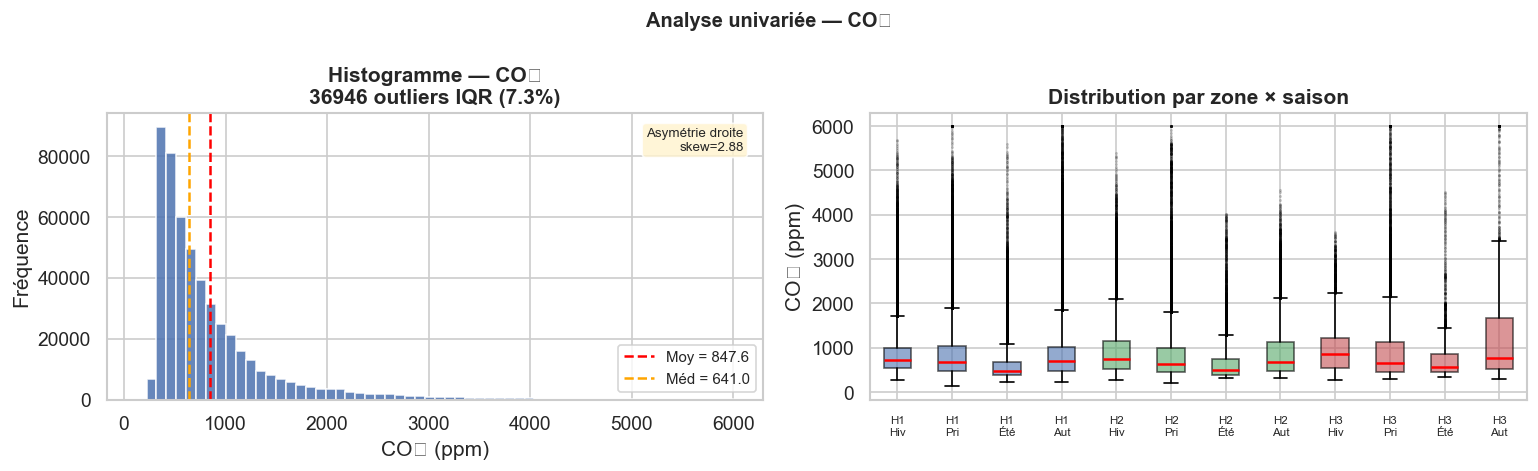

In [4]:
analyse_quant(co2_e['VALEUR'], 'CO₂', 'ppm', color='#4C72B0', clip_hi=6000,
              zone_s=co2_e['zone_climatique'], saison_s=co2_e['saison'])


──────────────────────────────────────────────────────────
  Température intérieure  [°C]
──────────────────────────────────────────────────────────
  Moyenne            :        20.80
  Médiane            :        20.90
  Écart-type         :         3.23
  Min                :         0.60
  Q1 (25%)           :        19.00
  Q3 (75%)           :        22.80
  Max                :        38.90
  Skewness           :        -0.44
  Kurtosis           :         1.75
  Outliers IQR       :     12699.00
  % Outliers         :         2.50


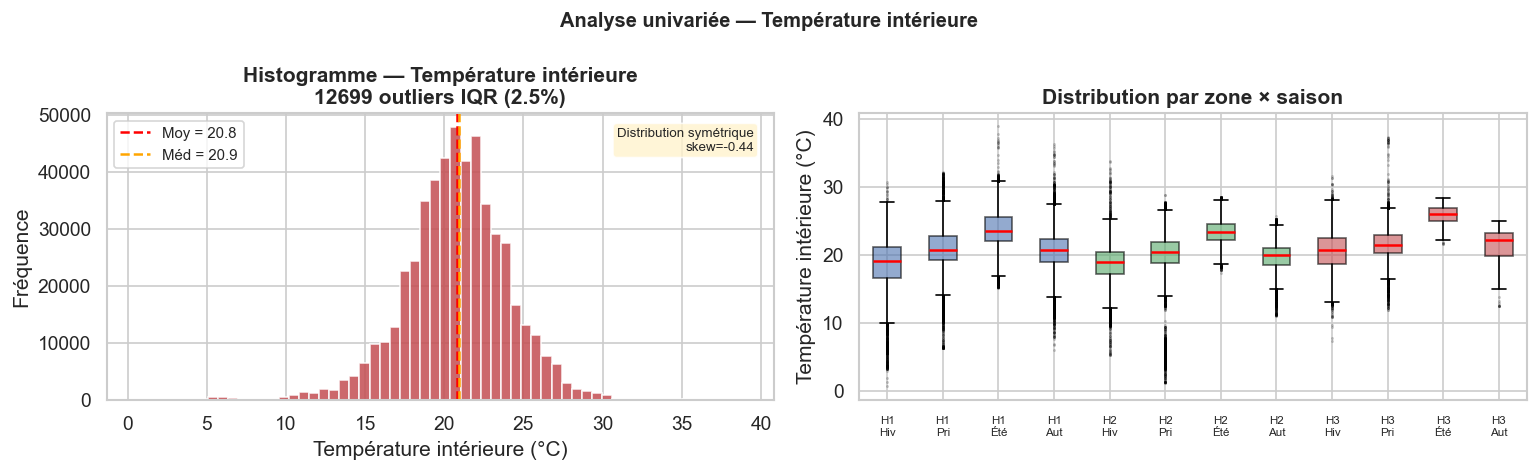

In [5]:
analyse_quant(confort_e['VALEUR_TPT'], 'Température intérieure', '°C', color='#C44E52',
              zone_s=confort_e['zone_climatique'], saison_s=confort_e['saison'])


──────────────────────────────────────────────────────────
  Humidité relative  [%]
──────────────────────────────────────────────────────────
  Moyenne            :        48.60
  Médiane            :        48.40
  Écart-type         :        10.01
  Min                :        17.00
  Q1 (25%)           :        41.80
  Q3 (75%)           :        55.50
  Max                :        90.40
  Skewness           :         0.07
  Kurtosis           :        -0.22
  Outliers IQR       :      1548.00
  % Outliers         :         0.31


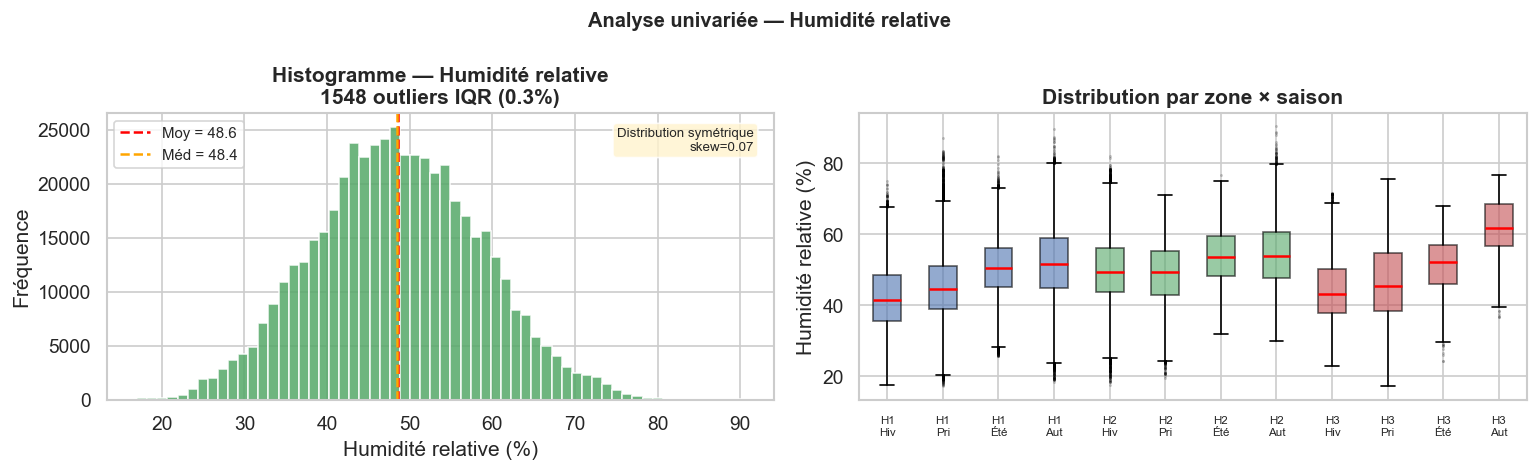

In [6]:
analyse_quant(confort_e['VALEUR_HRE'], 'Humidité relative', '%', color='#55A868',
              zone_s=confort_e['zone_climatique'], saison_s=confort_e['saison'])

Valeurs négatives CO : 74,885 (2.60%)

──────────────────────────────────────────────────────────
  CO  [mg/m³]
──────────────────────────────────────────────────────────
  Moyenne            :         0.28
  Médiane            :         0.00
  Écart-type         :         1.59
  Min                :        -3.00
  Q1 (25%)           :         0.00
  Q3 (75%)           :         0.00
  Max                :       311.00
  Skewness           :        22.32
  Kurtosis           :      1751.89
  Outliers IQR       :    402888.00
  % Outliers         :        14.01


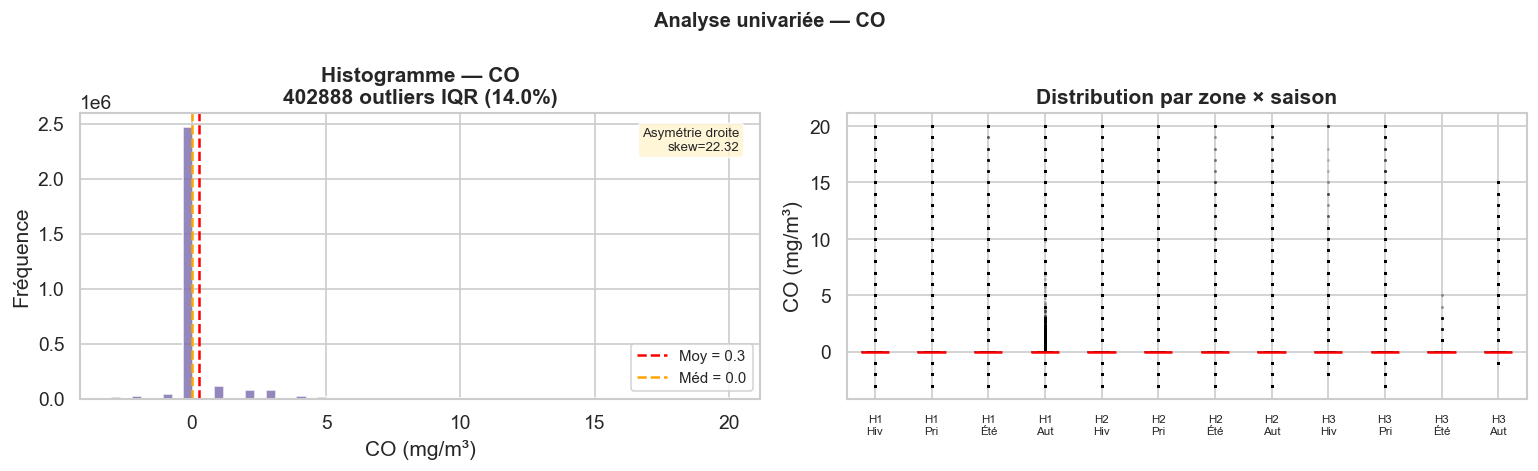

In [7]:
print(f"Valeurs négatives CO : {(co_e['VALEUR'] < 0).sum():,} ({100*(co_e['VALEUR']<0).mean():.2f}%)")
analyse_quant(co_e['VALEUR'], 'CO', 'mg/m³', color='#8172B2', clip_hi=20,
              zone_s=co_e['zone_climatique'], saison_s=co_e['saison'])

## 9. Variables de logement — Analyse qualitative & quantitative


───────────────────────────────────────────────────────
  Zone climatique RT2012   Modalités=3
  Mode : H1  (63.3%)
───────────────────────────────────────────────────────
                   N  % (non-NaN)
zone_climatique                  
H1               359        63.30
H2               155        27.30
H3                53         9.30


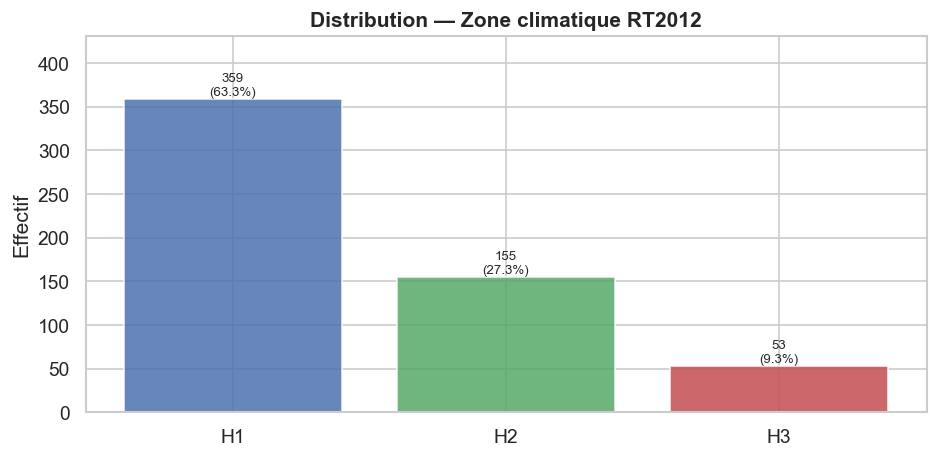


───────────────────────────────────────────────────────
  Saison de mesure   Modalités=4
  Mode : Printemps  (29.6%)
───────────────────────────────────────────────────────
             N  % (non-NaN)
saison                     
Printemps  168        29.60
Automne    152        26.80
Hiver      137        24.20
Été        110        19.40


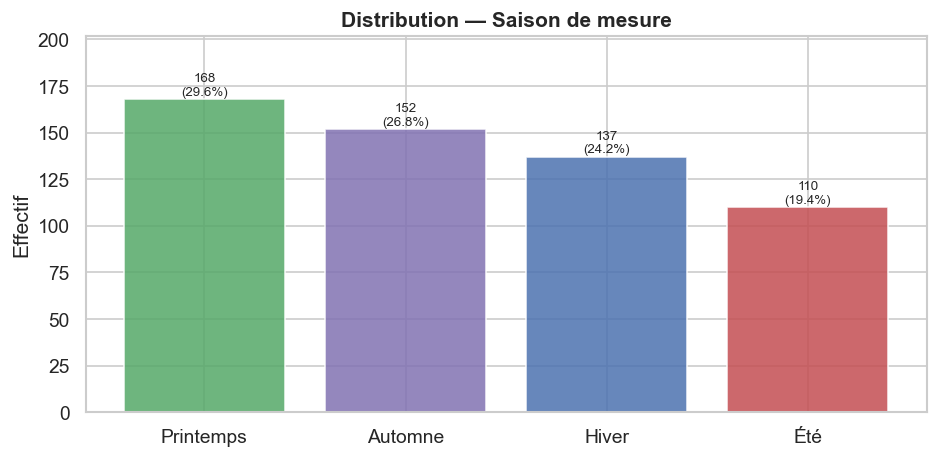


───────────────────────────────────────────────────────
  Type de logement   Modalités=3
  Mode : Maison  (59.4%)
───────────────────────────────────────────────────────
                 N  % (non-NaN)
type_logement                  
Maison         337        59.40
Appartement    218        38.40
Autre           12         2.10


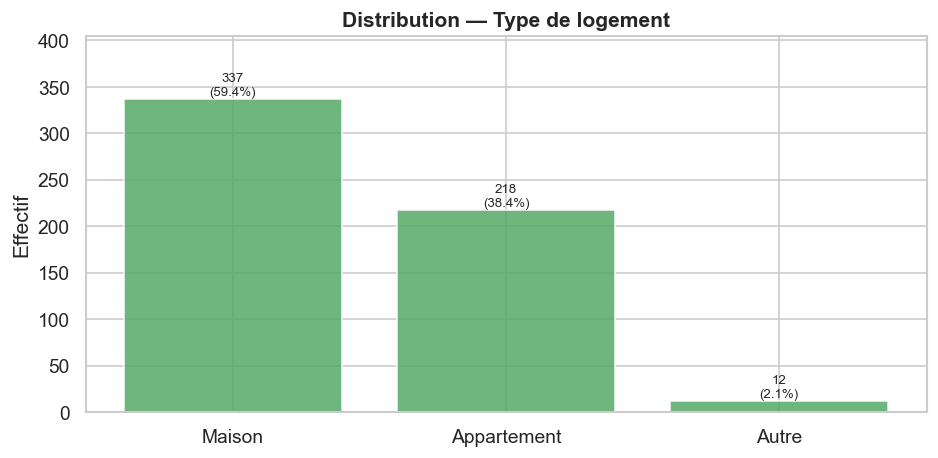


───────────────────────────────────────────────────────
  Département (top 15)   Modalités=50
  Mode : Paris  (5.3%)
───────────────────────────────────────────────────────
                 N  % (non-NaN)
DEPARTEMENT                    
Paris           30         5.30
Pas-de-Calais   26         4.60
Rhône           22         3.90
Manche          22         3.90
Val-de-Marne    21         3.70
Drôme           19         3.40
Bas-Rhin        19         3.40
Maine-et-Loire  18         3.20
Seine-et-Marne  18         3.20
Loire           18         3.20
Seine-St-Denis  18         3.20
Var             17         3.00
Aisne           17         3.00
Hauts-de-Seine  16         2.80
Yvelines        14         2.50


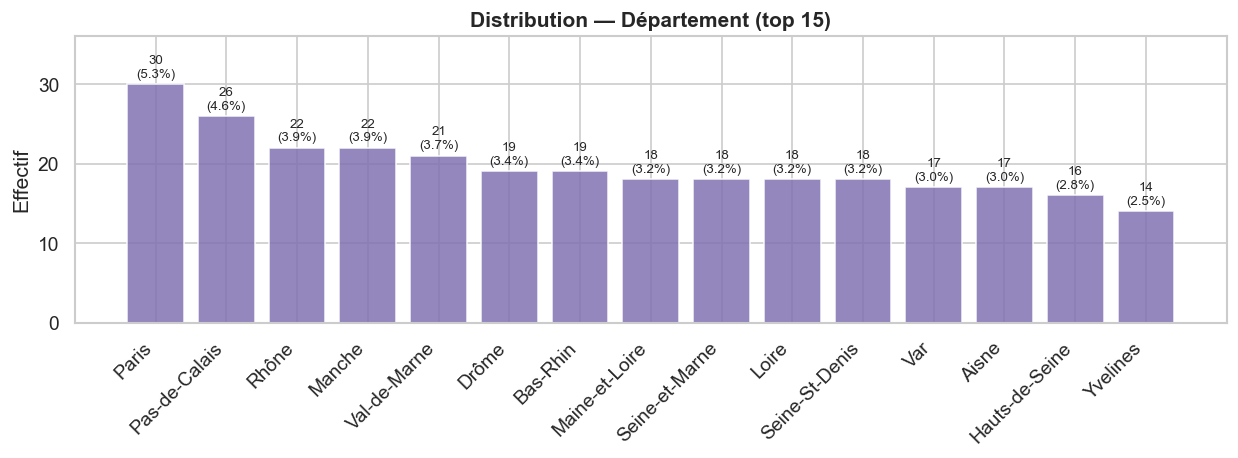

In [8]:
def analyse_qual(series, label, color='#4C72B0', top_n=None, rotate=0):
    """Fréquences absolues/relatives + mode + barplot pour une variable qualitative."""
    series = pd.Series(series)
    s = series.dropna()

    # Respecter l'ordre catégoriel si défini, sinon trier par fréquence
    if hasattr(s, 'cat') and s.cat.ordered:
        vc = s.value_counts().reindex(s.cat.categories).dropna()
    else:
        vc = s.value_counts()

    if top_n:
        vc = vc.head(top_n)
    vc_pct = (vc / len(s) * 100).round(1)

    print(f"\n{'─'*55}")
    print(f"  {label}   Modalités={s.nunique()}")
    print(f"  Mode : {s.mode().iloc[0]}  ({vc_pct.iloc[0]:.1f}%)")
    print(f"{'─'*55}")
    print(pd.DataFrame({'N': vc, '% (non-NaN)': vc_pct}).to_string())

    fig, ax = plt.subplots(figsize=(max(8, len(vc)*0.7), 4))
    bars = ax.bar(range(len(vc)), vc.values,
                  color=[color]*len(vc) if isinstance(color, str) else color,
                  edgecolor='white', alpha=0.85)
    for bar, val, pct in zip(bars, vc.values, vc_pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val}\n({pct}%)', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=rotate, ha='right' if rotate > 0 else 'center')
    ax.set_ylabel('Effectif')
    ax.set_title(f'Distribution — {label}', fontweight='bold')
    ax.set_ylim(0, vc.max() * 1.2)
    plt.tight_layout()
    plt.show()

analyse_qual(log['zone_climatique'], 'Zone climatique RT2012',
             color=[ZONE_COLORS.get(z,'grey') for z in log['zone_climatique'].value_counts().index])
analyse_qual(log['saison'], 'Saison de mesure',
             color=[SAIS_COLORS.get(s,'grey') for s in log['saison'].value_counts().index])
analyse_qual(log['type_logement'], 'Type de logement', color='#55A868')
analyse_qual(log['DEPARTEMENT'], 'Département (top 15)', color='#8172B2', top_n=15, rotate=45)


──────────────────────────────────────────────────────────
  Surface du logement  [m²]
──────────────────────────────────────────────────────────
  Moyenne            :       110.19
  Médiane            :        98.00
  Écart-type         :        66.24
  Min                :         7.00
  Q1 (25%)           :        70.00
  Q3 (75%)           :       134.00
  Max                :       700.00
  Skewness           :         3.04
  Kurtosis           :        18.22
  Outliers IQR       :        24.00
  % Outliers         :         4.29


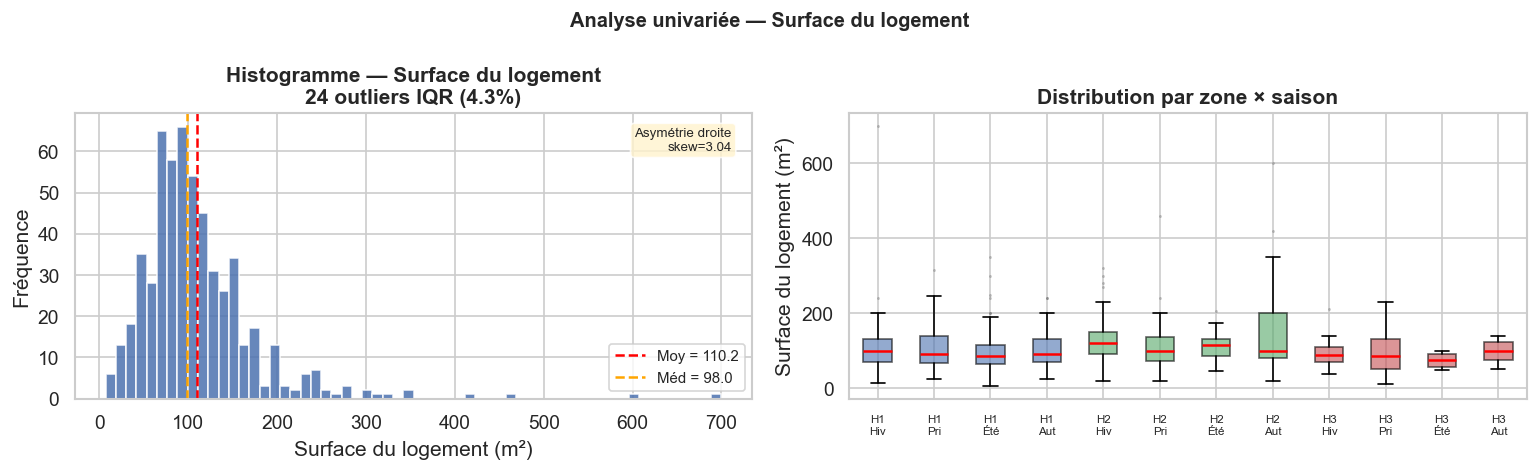


───────────────────────────────────────────────────────
  Nombre d'occupants   Modalités=8
  Mode : 2  (32.8%)
───────────────────────────────────────────────────────
        N  % (non-NaN)
FC10                  
2     186        32.80
4     112        19.80
1      99        17.50
3      92        16.20
5      65        11.50
6       7         1.20
7       5         0.90
8       1         0.20


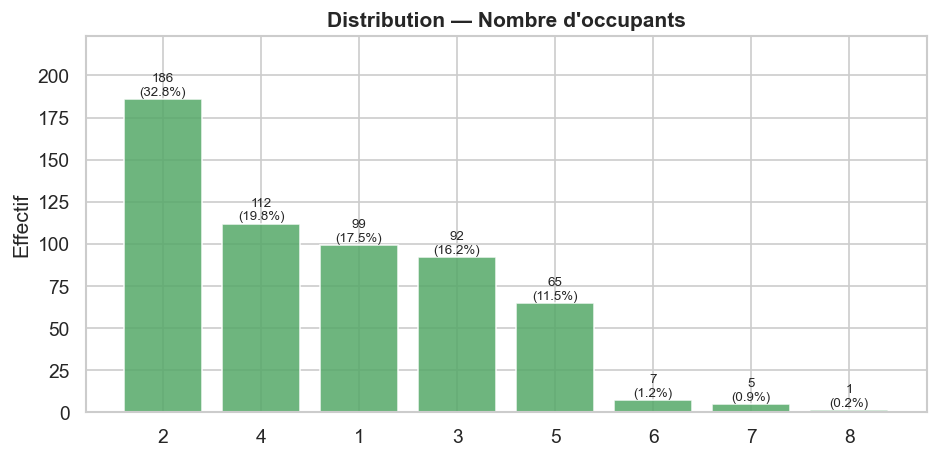


───────────────────────────────────────────────────────
  Nombre de pièces principales   Modalités=8
  Mode : 4  (29.6%)
───────────────────────────────────────────────────────
       N  % (non-NaN)
NPP                  
4    168        29.60
3    136        24.00
5    111        19.60
2     75        13.20
6     36         6.30
1     26         4.60
7     14         2.50
10     1         0.20


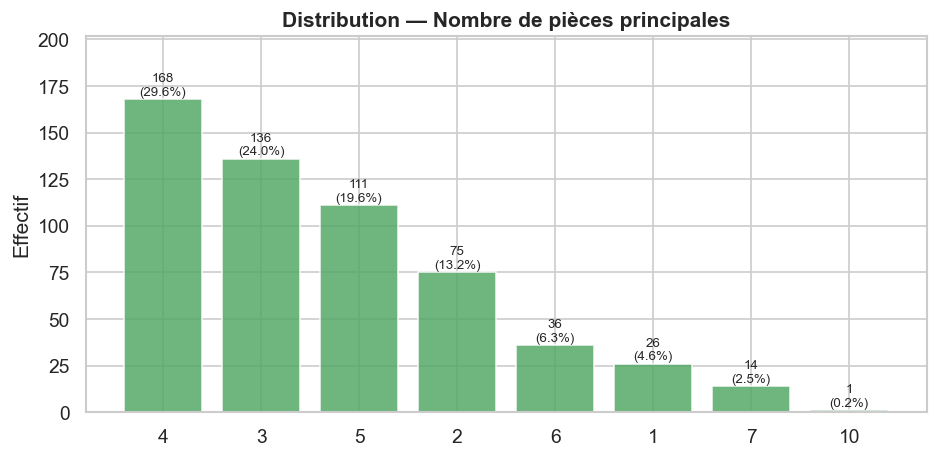


───────────────────────────────────────────────────────
  Type de ventilation   Modalités=4
  Mode : VMC mécanique  (37.2%)
───────────────────────────────────────────────────────
                     N  % (non-NaN)
KVNT                               
VMC mécanique      211        37.20
Ouvertures seules  187        33.00
Aucune             117        20.60
Ventilateurs        52         9.20


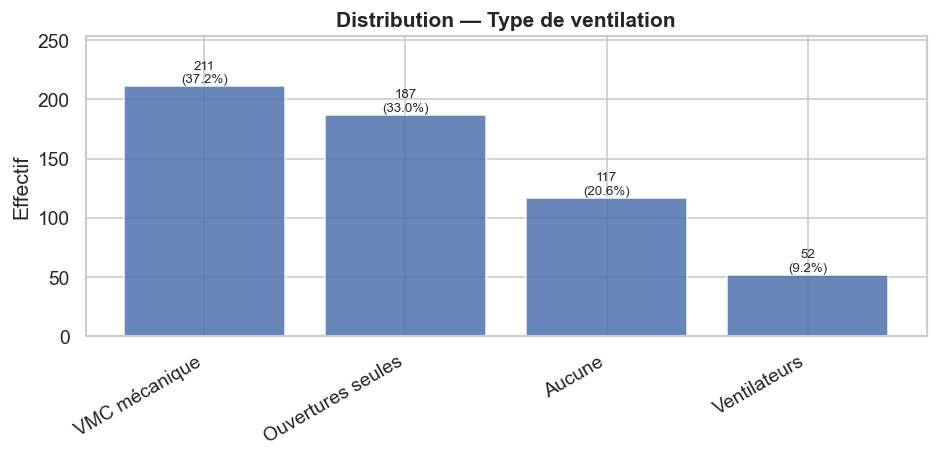


───────────────────────────────────────────────────────
  Système de chauffage   Modalités=7
  Mode : Gaz  (48.9%)
───────────────────────────────────────────────────────
              N  % (non-NaN)
KCC                         
Gaz         277        48.90
Élec.indiv  146        25.80
Fioul        51         9.00
Aucun        44         7.80
Bois         31         5.50
Urbain       13         2.30
Élec.mixte    4         0.70


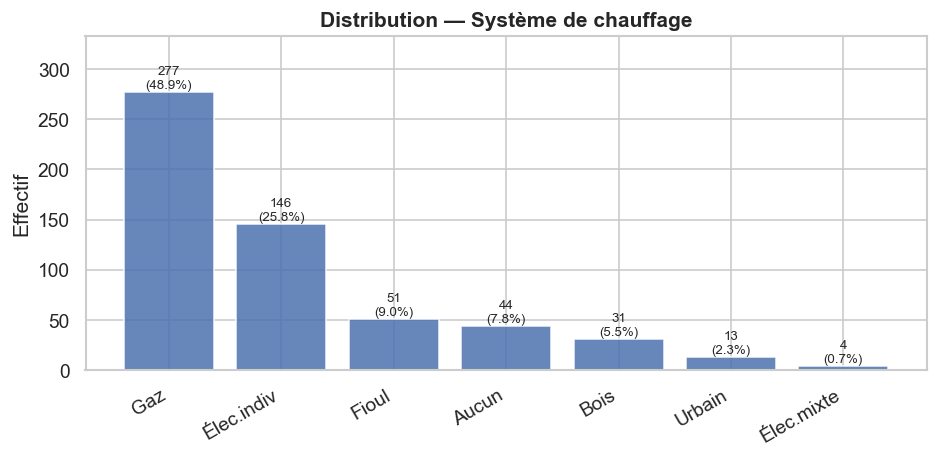


───────────────────────────────────────────────────────
  Période de construction   Modalités=9
  Mode : 1990+  (8.5%)
───────────────────────────────────────────────────────
            N  % (non-NaN)
<1871      48         8.50
1871–1914  80        14.10
1915–1948  59        10.40
1949–1961  50         8.80
1962–1967  51         9.00
1968–1974  70        12.30
1975–1981  59        10.40
1982–1989  66        11.60
1990+      84        14.80


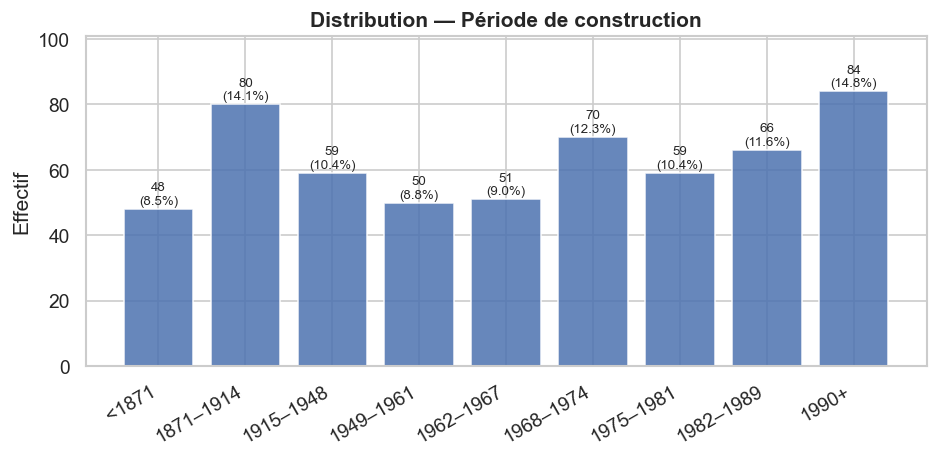

In [9]:
#  Surface du logement 
q_men_num = q_men_e.copy()
for c in ['HSRF','FC10','NPP']:
    q_men_num[c] = pd.to_numeric(q_men_num[c], errors='coerce')

analyse_quant(q_men_num['HSRF'], 'Surface du logement', 'm²', color='#4C72B0',
              zone_s=q_men_num['zone_climatique'], saison_s=q_men_num['saison'])

#  Nb occupants & nb pièces 
for col, label in [('FC10', "Nombre d'occupants"), ('NPP', 'Nombre de pièces principales')]:
    analyse_qual(q_men_num[col].dropna().astype(int).astype(str),
                 label, color='#55A868')

#  Variables qualitatives bâtiment 
KCC_LABEL  = {1:'Aucun', 2:'Urbain', 3:'Élec.mixte', 4:'Élec.indiv',
              5:'Gaz', 6:'Fioul', 7:'Bois', 8:'Autre'}
KVNT_LABEL = {1:'VMC mécanique', 2:'Ventilateurs', 3:'Ouvertures seules', 4:'Aucune'}
IAC_LABEL  = {1:'<1871', 2:'1871–1914', 3:'1915–1948', 4:'1949–1961',
              5:'1962–1967', 6:'1968–1974', 7:'1975–1981', 8:'1982–1989', 9:'1990+'}

for col, label, mapping in [
    ('KVNT', 'Type de ventilation',    KVNT_LABEL),
    ('KCC',  'Système de chauffage',   KCC_LABEL),
    ('IAC',  'Période de construction', IAC_LABEL),
]:
    s_raw = pd.to_numeric(q_men_e[col], errors='coerce')
    s_lab = s_raw.map(mapping)
    if col == 'IAC':
        # Ordre chronologique obligatoire pour une période
        ordered = [IAC_LABEL[k] for k in sorted(IAC_LABEL)]
        s_lab = pd.Categorical(s_lab, categories=ordered, ordered=True)
    analyse_qual(s_lab, label, color='#4C72B0', rotate=30)

## 10. Variables occupants — Analyse qualitative & quantitative


──────────────────────────────────────────────────────────
  Âge des occupants  [ans]
──────────────────────────────────────────────────────────
  Moyenne            :        34.36
  Médiane            :        35.00
  Écart-type         :        21.18
  Min                :         0.00
  Q1 (25%)           :        16.00
  Q3 (75%)           :        50.00
  Max                :        91.00
  Skewness           :         0.19
  Kurtosis           :        -0.99
  Outliers IQR       :         0.00
  % Outliers         :         0.00


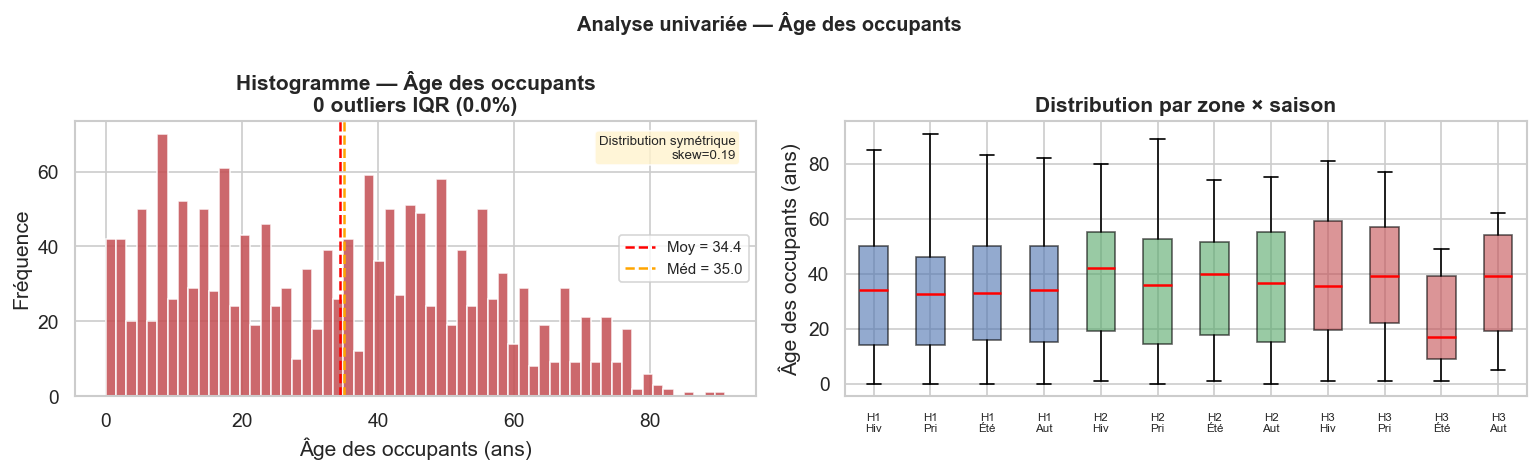


───────────────────────────────────────────────────────
  Nombre d'individus par logement   Modalités=8
  Mode : 2  (32.8%)
───────────────────────────────────────────────────────
     N  % (non-NaN)
2  186        32.80
4  112        19.80
1   97        17.10
3   93        16.40
5   65        11.50
6    8         1.40
7    5         0.90
8    1         0.20


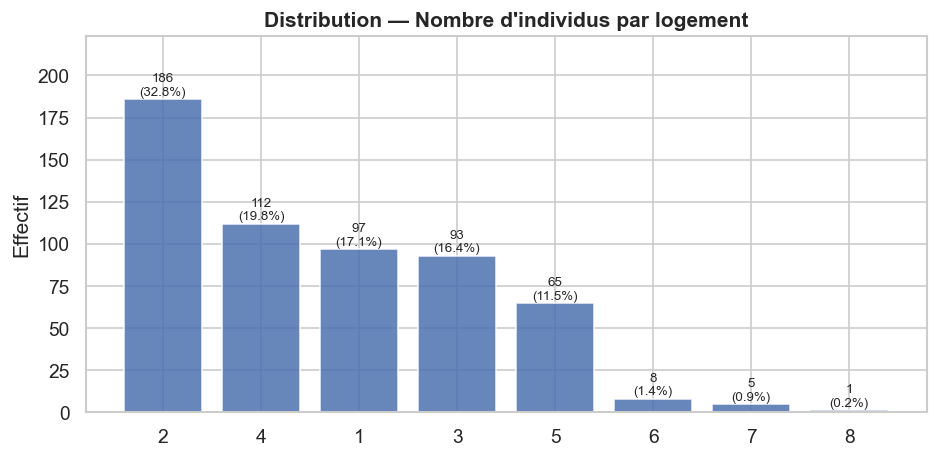


───────────────────────────────────────────────────────
  Sexe des occupants   Modalités=2
  Mode : Femme  (50.3%)
───────────────────────────────────────────────────────
         N  % (non-NaN)
SEXE                   
Femme  811        50.30
Homme  801        49.70


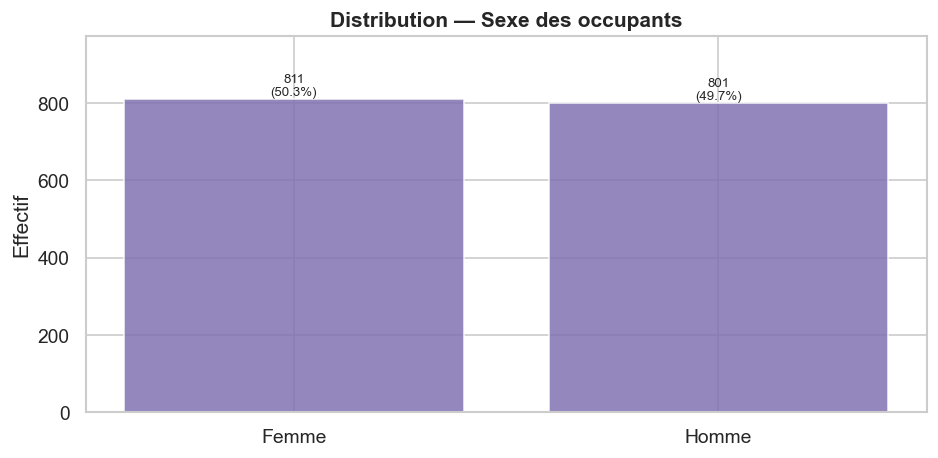


───────────────────────────────────────────────────────
  Statut tabagique   Modalités=3
  Mode : Non fumeur  (61.9%)
───────────────────────────────────────────────────────
                  N  % (non-NaN)
FUM0                            
Non fumeur      979        61.90
Fumeur          351        22.20
Non applicable  251        15.90


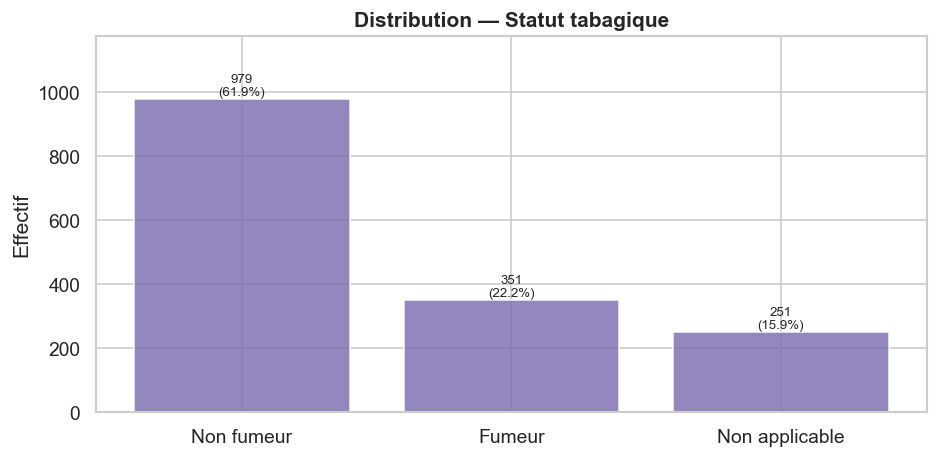


───────────────────────────────────────────────────────
  Niveau d'études   Modalités=8
  Mode : Supérieur  (26.7%)
───────────────────────────────────────────────────────
              N  % (non-NaN)
NIVETU                      
Supérieur   401        26.70
CAP/BEP     261        17.40
1er cycle   216        14.40
2ème cycle  200        13.30
Primaire    125         8.30
Bac techno  112         7.50
Pré-prim.   100         6.70
Jamais       85         5.70


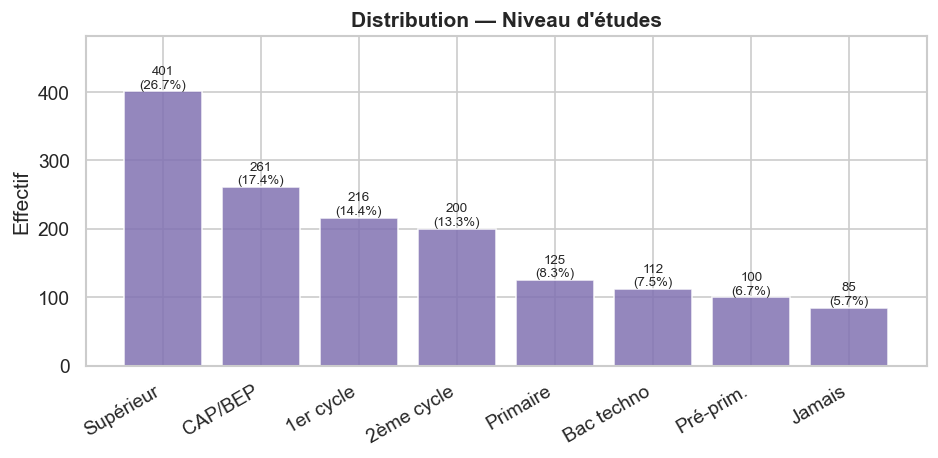

In [10]:
#  Âge (continu) avec segmentation zone × saison 
q_ind_num = q_ind_e.copy()
q_ind_num['AGE'] = pd.to_numeric(q_ind_num['AGE'], errors='coerce')

analyse_quant(q_ind_num['AGE'], 'Âge des occupants', 'ans', color='#C44E52',
              zone_s=q_ind_num['zone_climatique'], saison_s=q_ind_num['saison'])

#  Nb individus par logement 
nb_occ = q_ind_e.groupby('CODELIEU').size().astype(str)
analyse_qual(nb_occ, "Nombre d'individus par logement", color='#4C72B0')

#  Variables qualitatives occupants 
NIVETU_LABEL = {
    0: 'Jamais', 3: 'Pré-prim.', 4: 'Primaire',
    11: '1er cycle', 12: '2ème cycle', 20: 'CAP/BEP',
    30: 'Bac techno', 40: 'Supérieur'
}
SEXE_LABEL = {1: 'Homme', 2: 'Femme'}
# Après clean_q() : 0=Non fumeur, 1=Fumeur, 2=Non applicable
FUM_LABEL  = {0: 'Non fumeur', 1: 'Fumeur', 2: 'Non applicable'}

for col, label, mapping, rot in [
    ('SEXE',   'Sexe des occupants',  SEXE_LABEL,   0),
    ('FUM0',   'Statut tabagique',    FUM_LABEL,    0),
    ('NIVETU', "Niveau d'études",     NIVETU_LABEL, 30),
]:
    s_raw = pd.to_numeric(q_ind_e[col], errors='coerce')
    analyse_qual(s_raw.map(mapping), label, color='#8172B2', rotate=rot)